## Goal: 
Given a bookshelf photo, detect spines, extract text from each spine, match it to a real book in Google Books, and output structured metadata.

Pipeline:
1. **Detection** — Faster R-CNN (book-only, from Check-in 2 baseline)
2. **OCR** — Test many OCR and VLM options with multi-rotation (0/90/180/270°)
3. **Candidate retrieval** — Google Books API query from OCR text
4. **CLIP matching** — embed OCR text + candidate `title + author`, cosine similarity
5. **Hungarian assignment** — enforce one-to-one matching across a shelf (fixes series collisions)
6. **Output** — per spine: bbox, OCR text, matched title/author, Google Books `volumeId`

Inspired by:
- *Image-text matching for large-scale book collections* (arXiv 2407.19812) — CLIP + Hungarian matching
- *Research on a Method for Recognizing Text on Book Spines in Libraries* (MDPI Electronics 14/23/4689) — detection + tuned OCR


In [ ]:
import os
import json
import time
from pathlib import Path
from typing import List, Dict, Tuple, Optional

import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Load environment variables from .env (e.g. GOOGLE_BOOKS_API_KEY).
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

DATA_DIR = Path("data/LibVision-2")
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

BOOK_CLASS_ID = 0          # in data.yaml, 'book' is class 0
NUM_CLASSES = 2            # background + book
DET_SCORE_THRESH = 0.5     # detector score threshold
CROP_PAD_FRAC = 0.05       # padding around each predicted box before OCR
OCR_ROTATIONS = [0, 90, 180, 270]
OCR_MIN_SHORT_SIDE = 320   # upscale spine crops so short side >= this before OCR
OCR_TOKEN_CONF_MIN = 0.30  # drop OCR tokens below this confidence before joining
OCR_BACKEND = "paddleocr"    # "paddleocr" as baseline
GB_TOPK = 20               # candidates pulled per query from Google Books
CLIP_MODEL_NAME = "ViT-B-32"
CLIP_PRETRAINED = "laion2b_s34b_b79k"

WEIGHTS_PATH = Path("models/fasterrcnn_book.pt")
WEIGHTS_PATH.parent.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


## 1) Spine detector (Faster R-CNN)

Loads weights from `models/fasterrcnn_book.pt` if present; otherwise does a short fine-tune on `data/LibVision-2/train` and saves weights for future runs.


In [2]:
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone
from torchvision.models import ResNet18_Weights
from torchvision.transforms import ToTensor
from torch.utils.data import Dataset, DataLoader


def _yolo_line_to_box(coords, w, h):
    if len(coords) == 4:
        cx, cy, bw, bh = coords
        return [(cx - bw / 2) * w, (cy - bh / 2) * h, (cx + bw / 2) * w, (cy + bh / 2) * h]
    if len(coords) >= 6 and len(coords) % 2 == 0:
        xs, ys = coords[0::2], coords[1::2]
        return [min(xs) * w, min(ys) * h, max(xs) * w, max(ys) * h]
    return None


class LibVisionBookDetection(Dataset):
    def __init__(self, image_paths, labels_dir):
        self.image_paths = list(image_paths)
        self.labels_dir = Path(labels_dir)
        self.to_tensor = ToTensor()

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label_path = self.labels_dir / f"{img_path.stem}.txt"
        with Image.open(img_path) as im:
            img = im.convert("RGB")
        w, h = img.size

        boxes, labels = [], []
        if label_path.exists():
            for raw in label_path.read_text().splitlines():
                parts = raw.strip().split()
                if not parts:
                    continue
                cls_id = int(float(parts[0]))
                if cls_id != BOOK_CLASS_ID:
                    continue
                box = _yolo_line_to_box([float(x) for x in parts[1:]], w, h)
                if box is None:
                    continue
                x1, y1, x2, y2 = box
                if x2 > x1 and y2 > y1:
                    boxes.append([x1, y1, x2, y2])
                    labels.append(1)

        return self.to_tensor(img), {
            "boxes": torch.as_tensor(boxes, dtype=torch.float32),
            "labels": torch.as_tensor(labels, dtype=torch.int64),
        }


def detection_collate(batch):
    images, targets = [], []
    for img, tgt in batch:
        if tgt["boxes"].numel() == 0:
            continue
        images.append(img)
        targets.append(tgt)
    return images, targets


def build_faster_rcnn():
    backbone = resnet_fpn_backbone(backbone_name="resnet18", weights=ResNet18_Weights.DEFAULT)
    return FasterRCNN(backbone, num_classes=NUM_CLASSES)


def train_detector(model, epochs=3, lr=0.005):
    train_dir = DATA_DIR / "train"
    image_paths = sorted([p for p in (train_dir / "images").iterdir()
                          if p.is_file() and p.suffix.lower() in IMAGE_EXTS])
    ds = LibVisionBookDetection(image_paths, train_dir / "labels")
    loader = DataLoader(ds, batch_size=4, shuffle=True, collate_fn=detection_collate)

    params = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.SGD(params, lr=lr, momentum=0.9, weight_decay=5e-4)

    model.train()
    for epoch in range(epochs):
        running = 0.0
        n = 0
        for images, targets in loader:
            if not images:
                continue
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            loss_dict = model(images, targets)
            loss = sum(loss_dict.values())

            opt.zero_grad()
            loss.backward()
            opt.step()

            running += float(loss.detach().cpu())
            n += 1
        print(f"epoch {epoch+1}/{epochs}  loss={running / max(1, n):.4f}")
    return model


model = build_faster_rcnn().to(device)

if WEIGHTS_PATH.exists():
    model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device))
    print(f"Loaded weights from {WEIGHTS_PATH}")
else:
    print(f"No weights at {WEIGHTS_PATH}, fine-tuning on {DATA_DIR}/train ...")
    train_detector(model, epochs=3)
    torch.save(model.state_dict(), WEIGHTS_PATH)
    print(f"Saved weights to {WEIGHTS_PATH}")

model.eval()


Loaded weights from models/fasterrcnn_book.pt


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride

## 2) Spine detection on a full image

Runs the detector, applies a score threshold, and produces padded crops ready for OCR.


In [3]:
def _pad_box(x1, y1, x2, y2, W, H, frac=CROP_PAD_FRAC):
    bw = x2 - x1
    bh = y2 - y1
    px = bw * frac
    py = bh * frac
    return (
        max(0, int(x1 - px)),
        max(0, int(y1 - py)),
        min(W, int(x2 + px)),
        min(H, int(y2 + py)),
    )


def detect_spines(pil_img: Image.Image, score_thresh: float = DET_SCORE_THRESH):
    """Return list of dicts: {bbox: (x1,y1,x2,y2), score: float, crop: PIL.Image}."""
    model.eval()
    W, H = pil_img.size

    img_t = ToTensor()(pil_img).to(device)
    with torch.no_grad():
        pred = model([img_t])[0]

    boxes = pred["boxes"].detach().cpu().numpy()
    labels = pred["labels"].detach().cpu().numpy()
    scores = pred["scores"].detach().cpu().numpy()

    spines = []
    for (x1, y1, x2, y2), lab, sc in zip(boxes, labels, scores):
        if lab != 1 or sc < score_thresh:
            continue
        px1, py1, px2, py2 = _pad_box(x1, y1, x2, y2, W, H)
        crop = pil_img.crop((px1, py1, px2, py2))
        spines.append({
            "bbox": (float(x1), float(y1), float(x2), float(y2)),
            "score": float(sc),
            "crop": crop,
        })
    return spines


## 3) OCR with multi-rotation

Book spines often have vertical text and small fonts. We:
1. Upscale the crop so the short side is ≥ `OCR_MIN_SHORT_SIDE` px.
2. Autocontrast for stylized covers.
3. Run OCR at 0°/90°/180°/270° with the selected backend (`OCR_BACKEND`).
4. Drop tokens with confidence below `OCR_TOKEN_CONF_MIN` and pick the rotation with the largest *confidence mass* of kept tokens.

Supported backends: `"easyocr"`, `"paddleocr"`, `"trocr"`, `"trocr hybrid"`, `"florence"`. They share identical preprocessing and rotation logic so any quality gap is due to the OCR model itself.


In [13]:
from PIL import ImageOps
import logging

_easyocr_reader = None
_paddleocr_reader = None
_trocr_cache: Dict[str, dict] = {}
_florence = None


def _get_easyocr():
    global _easyocr_reader
    if _easyocr_reader is None:
        import easyocr
        _easyocr_reader = easyocr.Reader(["en"], gpu=(device.type == "cuda"))
    return _easyocr_reader


def _build_paddleocr():
    import paddle
    from paddleocr import PaddleOCR

    paddle_has_cuda = bool(getattr(paddle, "is_compiled_with_cuda", lambda: False)())
    use_gpu = (device.type == "cuda") and paddle_has_cuda
    gpu_kw_3x = {"device": "gpu"} if use_gpu else {"device": "cpu", "enable_mkldnn": False}

    attempts = [
        dict(lang="en", use_textline_orientation=False, **gpu_kw_3x),
        dict(lang="en", **gpu_kw_3x),
        dict(lang="en", use_angle_cls=False,
             **({"use_gpu": True} if use_gpu else {"use_gpu": False, "enable_mkldnn": False})),
        dict(lang="en", use_angle_cls=False),
        dict(lang="en"),
        dict(),
    ]
    last_err = None
    for kwargs in attempts:
        try:
            return PaddleOCR(**kwargs)
        except (TypeError, ValueError) as e:
            last_err = e
            continue
    raise RuntimeError(f"Could not construct PaddleOCR: {last_err}")


def _get_paddleocr():
    global _paddleocr_reader
    if _paddleocr_reader is None:
        if device.type != "cuda":
            os.environ.setdefault("FLAGS_use_mkldnn", "0")
        for noisy in ("ppocr", "paddle", "paddlex"):
            logging.getLogger(noisy).setLevel(logging.ERROR)
        _paddleocr_reader = _build_paddleocr()
    return _paddleocr_reader


def _materialize_meta_tensors(mdl, target_device, target_dtype):
    moved = 0
    for name, p in list(mdl.named_parameters(recurse=True)):
        if p.device.type == "meta":
            mod_path, _, attr = name.rpartition(".")
            mod = mdl.get_submodule(mod_path) if mod_path else mdl
            new_p = torch.nn.Parameter(
                torch.zeros(p.shape, dtype=target_dtype, device=target_device),
                requires_grad=False,
            )
            setattr(mod, attr, new_p)
            moved += 1
    for name, b in list(mdl.named_buffers(recurse=True)):
        if b.device.type == "meta":
            mod_path, _, attr = name.rpartition(".")
            mod = mdl.get_submodule(mod_path) if mod_path else mdl
            mod.register_buffer(
                attr, torch.zeros(b.shape, dtype=b.dtype, device=target_device),
            )
            moved += 1
    return moved


def _get_trocr(model_name: str):
    global _trocr_cache
    if model_name not in _trocr_cache:
        from transformers import TrOCRProcessor, VisionEncoderDecoderModel
        target = "cuda:0" if device.type == "cuda" else "cpu"
        torch_dtype = torch.float32

        proc = TrOCRProcessor.from_pretrained(model_name)
        try:
            mdl = VisionEncoderDecoderModel.from_pretrained(
                model_name, torch_dtype=torch_dtype, device_map={"": target},
            )
        except (TypeError, ValueError):
            mdl = VisionEncoderDecoderModel.from_pretrained(
                model_name, torch_dtype=torch_dtype
            ).to(target)

        leftovers = _materialize_meta_tensors(mdl, torch.device(target), torch_dtype)
        if leftovers:
            print(f"[trocr:{model_name}] materialized {leftovers} leftover meta tensors -> {target}")

        mdl.eval()
        _trocr_cache[model_name] = {
            "processor": proc, "model": mdl, "name": model_name,
            "device": target, "dtype": torch_dtype,
        }
    return _trocr_cache[model_name]


# Legacy generation attrs newer transformers removed from PretrainedConfig
# but Florence-2's custom config code still expects to see.
_FLORENCE_LEGACY_DEFAULTS = {
    "forced_bos_token_id": None,
    "forced_eos_token_id": None,
    "begin_suppress_tokens": None,
    "suppress_tokens": None,
    "exponential_decay_length_penalty": None,
    "diversity_penalty": 0.0,
    "encoder_no_repeat_ngram_size": 0,
    "no_repeat_ngram_size": 0,
}


def _pre_patch_pretrained_config():
    """Inject class-level defaults on transformers.PretrainedConfig so Florence's
    custom config __init__ (which reads self.forced_bos_token_id before super()
    has a chance to set it) doesn't AttributeError. Idempotent."""
    from transformers import PretrainedConfig
    for k, v in _FLORENCE_LEGACY_DEFAULTS.items():
        # Only set if not already present as a class attribute.
        if k not in PretrainedConfig.__dict__:
            setattr(PretrainedConfig, k, v)


def _force_set(obj, key, value):
    try:
        obj.__dict__[key] = value
    except Exception:
        try:
            object.__setattr__(obj, key, value)
        except Exception:
            pass


def _patch_florence_config(mdl):
    """Best-effort instance-level patch after load (belt and suspenders)."""
    targets = [mdl.config]
    for name in ("text_config", "vision_config"):
        sub = getattr(mdl.config, name, None)
        if sub is not None:
            targets.append(sub)
    gc = getattr(mdl, "generation_config", None)
    if gc is not None:
        targets.append(gc)

    for cfg in targets:
        for k, v in _FLORENCE_LEGACY_DEFAULTS.items():
            _force_set(cfg, k, v)

    text_cfg = getattr(mdl.config, "text_config", None)
    if text_cfg is not None and not text_cfg.__dict__.get("decoder_start_token_id"):
        bos = text_cfg.__dict__.get("bos_token_id", 0)
        _force_set(text_cfg, "decoder_start_token_id", bos)


def _get_florence(model_name: str = "microsoft/Florence-2-base"):
    global _florence
    if _florence is None:
        _pre_patch_pretrained_config()  # must run BEFORE from_pretrained

        from transformers import AutoProcessor, AutoModelForCausalLM
        torch_dtype = torch.float16 if device.type == "cuda" else torch.float32
        target = "cuda:0" if device.type == "cuda" else "cpu"

        proc = AutoProcessor.from_pretrained(model_name, trust_remote_code=True)
        mdl = AutoModelForCausalLM.from_pretrained(
            model_name,
            trust_remote_code=True,
            torch_dtype=torch_dtype,
            device_map={"": target},
        )

        leftovers = _materialize_meta_tensors(mdl, torch.device(target), torch_dtype)
        if leftovers:
            print(f"[florence] materialized {leftovers} leftover meta tensors -> {target}")

        _patch_florence_config(mdl)
        mdl.eval()
        _florence = {"processor": proc, "model": mdl, "name": model_name,
                     "device": target, "dtype": torch_dtype}
    return _florence


def _preprocess_crop(crop: Image.Image, min_short_side: int = OCR_MIN_SHORT_SIDE) -> Image.Image:
    w, h = crop.size
    short = min(w, h)
    if short < min_short_side:
        scale = min_short_side / max(1, short)
        new_size = (max(1, int(round(w * scale))), max(1, int(round(h * scale))))
        crop = crop.resize(new_size, Image.LANCZOS)
    crop = ImageOps.autocontrast(crop, cutoff=2)
    return crop


def _easyocr_tokens(arr: np.ndarray) -> List[Tuple[str, float]]:
    reader = _get_easyocr()
    results = reader.readtext(arr, detail=1)
    return [(str(t), float(c)) for (_, t, c) in results]


def _paddleocr_tokens(arr: np.ndarray) -> List[Tuple[str, float]]:
    reader = _get_paddleocr()
    if hasattr(reader, "predict"):
        try:
            raw = reader.predict(arr)
            if not raw:
                return []
            res = raw[0]
            if isinstance(res, dict):
                texts = res.get("rec_texts", [])
                scores = res.get("rec_scores", [])
            else:
                texts = getattr(res, "rec_texts", []) or []
                scores = getattr(res, "rec_scores", []) or []
            return [(str(t), float(c)) for t, c in zip(texts, scores)]
        except Exception:
            pass
    try:
        raw = reader.ocr(arr)
    except Exception:
        return []
    if not raw or raw[0] is None:
        return []
    tokens: List[Tuple[str, float]] = []
    for line in raw[0]:
        try:
            text, conf = line[1]
        except Exception:
            continue
        tokens.append((str(text), float(conf)))
    return tokens


def _paddle_detect_polys(arr: np.ndarray) -> List[np.ndarray]:
    reader = _get_paddleocr()
    polys: List[np.ndarray] = []
    if hasattr(reader, "predict"):
        try:
            raw = reader.predict(arr)
            if not raw:
                return []
            res = raw[0]
            dt = (res.get("dt_polys") if isinstance(res, dict)
                  else getattr(res, "dt_polys", None))
            if dt is not None:
                for p in dt:
                    pa = np.asarray(p).reshape(-1, 2)
                    polys.append(pa)
        except Exception:
            polys = []
    if not polys:
        try:
            raw = reader.ocr(arr, rec=False)
            if raw and raw[0]:
                for p in raw[0]:
                    polys.append(np.asarray(p).reshape(-1, 2))
        except Exception:
            pass
    polys.sort(key=lambda p: float(p[:, 1].min()))
    return polys


def _crop_poly_bbox(arr: np.ndarray, poly: np.ndarray, pad: int = 2) -> Optional[Image.Image]:
    H, W = arr.shape[:2]
    xs, ys = poly[:, 0], poly[:, 1]
    x1 = max(0, int(np.floor(xs.min())) - pad)
    y1 = max(0, int(np.floor(ys.min())) - pad)
    x2 = min(W, int(np.ceil(xs.max())) + pad)
    y2 = min(H, int(np.ceil(ys.max())) + pad)
    if x2 <= x1 or y2 <= y1:
        return None
    return Image.fromarray(arr[y1:y2, x1:x2])


def _trocr_recognize_line(pil_line: Image.Image, model_name: str) -> Tuple[str, float]:
    bundle = _get_trocr(model_name)
    proc, mdl = bundle["processor"], bundle["model"]
    mdl_device = bundle["device"]
    mdl_dtype = bundle["dtype"]

    inputs = proc(images=pil_line, return_tensors="pt")
    moved = {}
    for k, v in inputs.items():
        if not isinstance(v, torch.Tensor):
            moved[k] = v
            continue
        v = v.to(mdl_device)
        if v.is_floating_point():
            v = v.to(mdl_dtype)
        moved[k] = v
    inputs = moved

    with torch.no_grad():
        gen = mdl.generate(**inputs, max_new_tokens=48, output_scores=True, return_dict_in_generate=True)
    text = proc.batch_decode(gen.sequences, skip_special_tokens=True)[0].strip()
    conf = 0.0
    try:
        if gen.scores:
            step_ps = [float(torch.softmax(s[0], dim=-1).max().item()) for s in gen.scores]
            conf = float(np.mean(step_ps)) if step_ps else 0.0
    except Exception:
        conf = 0.0
    return text, conf


def _trocr_tokens(arr: np.ndarray, model_name: str) -> List[Tuple[str, float]]:
    pil = Image.fromarray(arr) if not isinstance(arr, Image.Image) else arr
    text, conf = _trocr_recognize_line(pil, model_name)
    return [(text, conf)] if text else []


def _trocr_hybrid_tokens(arr: np.ndarray, model_name: str) -> List[Tuple[str, float]]:
    polys = _paddle_detect_polys(arr)
    if not polys:
        return _trocr_tokens(arr, model_name)
    tokens: List[Tuple[str, float]] = []
    for poly in polys:
        line_img = _crop_poly_bbox(arr, poly)
        if line_img is None or min(line_img.size) < 4:
            continue
        text, conf = _trocr_recognize_line(line_img, model_name)
        if text:
            tokens.append((text, conf))
    return tokens


def _florence_tokens(arr: np.ndarray, model_name: str = "microsoft/Florence-2-base") -> List[Tuple[str, float]]:
    bundle = _get_florence(model_name)
    proc, mdl = bundle["processor"], bundle["model"]
    mdl_device = bundle["device"]
    mdl_dtype = bundle["dtype"]

    pil = Image.fromarray(arr) if not isinstance(arr, Image.Image) else arr
    prompt = "<OCR>"

    inputs = proc(text=prompt, images=pil, return_tensors="pt")
    moved = {}
    for k, v in inputs.items():
        if not isinstance(v, torch.Tensor):
            moved[k] = v
            continue
        v = v.to(mdl_device)
        if v.is_floating_point():
            v = v.to(mdl_dtype)
        moved[k] = v
    inputs = moved

    with torch.no_grad():
        generated_ids = mdl.generate(
            input_ids=inputs["input_ids"],
            pixel_values=inputs.get("pixel_values"),
            max_new_tokens=128,
            num_beams=3,
        )

    gen_text = proc.batch_decode(generated_ids, skip_special_tokens=False)[0]
    try:
        parsed = proc.post_process_generation(gen_text, task=prompt, image_size=pil.size)
        val = parsed.get(prompt)
        if isinstance(val, str):
            text = val
        elif isinstance(val, dict) and "text" in val:
            text = val["text"]
        else:
            text = str(val) if val is not None else ""
    except Exception:
        text = gen_text

    text = str(text).strip()
    return [(text, 1.0)] if text else []


def _ocr_tokens(arr: np.ndarray, backend: str) -> List[Tuple[str, float]]:
    if backend == "easyocr":
        return _easyocr_tokens(arr)
    if backend == "paddleocr":
        return _paddleocr_tokens(arr)
    if backend == "trocr":
        return _trocr_tokens(arr, "microsoft/trocr-base-printed")
    if backend == "trocr_large":
        return _trocr_tokens(arr, "microsoft/trocr-large-printed")
    if backend == "trocr_hybrid":
        return _trocr_hybrid_tokens(arr, "microsoft/trocr-base-printed")
    if backend == "trocr_large_hybrid":
        return _trocr_hybrid_tokens(arr, "microsoft/trocr-large-printed")
    if backend == "florence":
        return _florence_tokens(arr, "microsoft/Florence-2-base")
    raise ValueError(f"Unknown OCR backend: {backend}")


_WHOLE_STRING_BACKENDS = {"trocr", "trocr_large", "florence"}


def _ocr_one_rotation(crop: Image.Image, angle: int, backend: str):
    rotated = crop.rotate(-angle, expand=True) if angle != 0 else crop
    rotated = _preprocess_crop(rotated)
    arr = np.asarray(rotated)
    tokens = _ocr_tokens(arr, backend)
    if backend in _WHOLE_STRING_BACKENDS:
        kept = [(t, float(c)) for (t, c) in tokens if str(t).strip()]
    else:
        kept = [(t, c) for (t, c) in tokens if c >= OCR_TOKEN_CONF_MIN]
    text = " ".join(t for t, _ in kept).strip()
    conf = float(np.mean([c for _, c in kept])) if kept else 0.0
    score = float(sum(c for _, c in kept))
    return {"text": text, "conf": conf, "score": score, "n_tokens": len(kept)}


def ocr_spine(crop: Image.Image,
              rotations: List[int] = OCR_ROTATIONS,
              backend: Optional[str] = None):
    backend = backend or OCR_BACKEND
    best = None
    for ang in rotations:
        cur = _ocr_one_rotation(crop, ang, backend)
        cur["rotation"] = ang
        if best is None or cur["score"] > best["score"]:
            best = cur
    if best is None:
        best = {"text": "", "conf": 0.0, "score": 0.0, "n_tokens": 0, "rotation": 0}
    best["backend"] = backend
    return best


## 4) Google Books candidate retrieval

For each spine's OCR text we hit the public Google Books API and collect up to `GB_TOPK` candidate books. We cache responses to avoid repeat calls.


In [5]:
import re
import requests

GB_CACHE_PATH = Path("cache/google_books.json")
GB_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
if GB_CACHE_PATH.exists():
    _gb_cache: Dict[str, List[dict]] = json.loads(GB_CACHE_PATH.read_text())
else:
    _gb_cache = {}

# Rate-limit / retry config for the public Google Books endpoint.
# Unauthenticated requests are aggressively throttled (HTTP 429). We keep a
# minimum gap between calls and back off exponentially on 429.
GB_MIN_INTERVAL_S = 1.1          # seconds between consecutive API calls
GB_MAX_RETRIES = 5               # attempts per query
GB_BACKOFF_BASE_S = 2.0          # initial backoff
GB_API_KEY = os.environ.get("GOOGLE_BOOKS_API_KEY", "").strip()  # optional

_gb_last_call_ts = 0.0


def _save_gb_cache():
    GB_CACHE_PATH.write_text(json.dumps(_gb_cache))


def _gb_throttle():
    global _gb_last_call_ts
    now = time.time()
    wait = GB_MIN_INTERVAL_S - (now - _gb_last_call_ts)
    if wait > 0:
        time.sleep(wait)
    _gb_last_call_ts = time.time()


def _sanitize_gb_query(text: str) -> str:
    """Normalize OCR output into a safer Google Books query string."""
    q = (text or "").strip()
    if not q:
        return ""

    # Replace common OCR garbage with spaces, keep letters/numbers/basic punctuation.
    q = re.sub(r"[^0-9A-Za-z '\-:&]", " ", q)
    q = re.sub(r"\s+", " ", q).strip()

    # Clamp length: long noisy strings increase failure rate and don't help retrieval.
    if len(q) > 80:
        q = q[:80].rsplit(" ", 1)[0].strip() or q[:80].strip()

    # Too-short queries are almost always junk.
    if len(q) < 3:
        return ""

    return q


def query_google_books(text: str, top_k: int = GB_TOPK) -> List[dict]:
    """Return list of candidate dicts: {title, authors, publisher, volumeId, thumbnail}.

    Uses an on-disk cache keyed by (query, top_k). Retries on rate-limit (429)
    and transient server errors (5xx) with exponential backoff.
    """
    q = _sanitize_gb_query(text)
    if not q:
        return []

    key = f"{q}|{top_k}"
    if key in _gb_cache:
        return _gb_cache[key]

    url = "https://www.googleapis.com/books/v1/volumes"
    params = {"q": q, "maxResults": min(40, top_k), "printType": "books"}
    if GB_API_KEY:
        params["key"] = GB_API_KEY

    data = None
    for attempt in range(GB_MAX_RETRIES):
        _gb_throttle()
        try:
            r = requests.get(url, params=params, timeout=10)
        except requests.RequestException as e:
            print(f"Google Books request error for {q!r} (attempt {attempt+1}/{GB_MAX_RETRIES}): {type(e).__name__}")
            time.sleep(GB_BACKOFF_BASE_S * (2 ** attempt))
            continue

        # Rate limit
        if r.status_code == 429:
            retry_after = r.headers.get("Retry-After")
            try:
                sleep_s = float(retry_after) if retry_after else GB_BACKOFF_BASE_S * (2 ** attempt)
            except ValueError:
                sleep_s = GB_BACKOFF_BASE_S * (2 ** attempt)
            print(f"Google Books 429 for {q!r} (attempt {attempt+1}/{GB_MAX_RETRIES}); sleeping {sleep_s:.1f}s")
            time.sleep(sleep_s)
            continue

        # Transient server errors
        if 500 <= r.status_code < 600:
            sleep_s = GB_BACKOFF_BASE_S * (2 ** attempt)
            print(f"Google Books {r.status_code} for {q!r} (attempt {attempt+1}/{GB_MAX_RETRIES}); sleeping {sleep_s:.1f}s")
            time.sleep(sleep_s)
            continue

        try:
            r.raise_for_status()
        except requests.HTTPError:
            print(f"Google Books HTTP {r.status_code} for {q!r}; not retrying")
            break

        try:
            data = r.json()
        except ValueError:
            print(f"Google Books bad JSON for {q!r}; not retrying")
            break
        break

    if data is None:
        # Cache empty result so we don't retry forever within a run.
        _gb_cache[key] = []
        _save_gb_cache()
        return []

    out = []
    for item in data.get("items", [])[:top_k]:
        vi = item.get("volumeInfo", {})
        out.append({
            "volumeId": item.get("id", ""),
            "title": vi.get("title", ""),
            "subtitle": vi.get("subtitle", ""),
            "authors": vi.get("authors", []),
            "publisher": vi.get("publisher", ""),
            "publishedDate": vi.get("publishedDate", ""),
            "thumbnail": vi.get("imageLinks", {}).get("thumbnail", ""),
        })

    _gb_cache[key] = out
    _save_gb_cache()
    return out


def candidate_text(cand: dict) -> str:
    authors = ", ".join(cand.get("authors", []) or [])
    return f"{cand.get('title', '')} {authors}".strip()


## 5a) CLIP text embeddings + Hungarian matching

Paper 1's core idea (*Image-text matching for large-scale book collections*): encode OCR text from spines and `title + author` from candidates with **CLIP's text encoder**, build a similarity matrix, then use the **Hungarian algorithm** to enforce a one-to-one matching across a shelf (prevents three series spines all mapping to book #1).


In [6]:
import open_clip
from scipy.optimize import linear_sum_assignment

_clip_model, _, _ = open_clip.create_model_and_transforms(CLIP_MODEL_NAME, pretrained=CLIP_PRETRAINED)
_clip_tokenizer = open_clip.get_tokenizer(CLIP_MODEL_NAME)
_clip_model = _clip_model.to(device).eval()


@torch.no_grad()
def clip_text_embed(texts: List[str]) -> torch.Tensor:
    if not texts:
        return torch.zeros((0, 512), device=device)
    tokens = _clip_tokenizer(texts).to(device)
    emb = _clip_model.encode_text(tokens)
    emb = emb / emb.norm(dim=-1, keepdim=True).clamp(min=1e-8)
    return emb


def build_similarity_matrix(spine_texts: List[str], candidates: List[dict]) -> np.ndarray:
    """S[i, j] = cosine similarity between spine i OCR text and candidate j (title+authors)."""
    if not spine_texts or not candidates:
        return np.zeros((len(spine_texts), len(candidates)), dtype=np.float32)

    cand_texts = [candidate_text(c) for c in candidates]
    sp_emb = clip_text_embed(spine_texts)
    cd_emb = clip_text_embed(cand_texts)
    S = (sp_emb @ cd_emb.T).detach().cpu().numpy()
    return S.astype(np.float32)


def hungarian_assign(S: np.ndarray, sim_threshold: float = 0.2):
    """Return list of (spine_idx, cand_idx, sim). Unassigned spines are omitted.

    Uses linear_sum_assignment on -S (maximize similarity).
    Rejects matches with similarity below `sim_threshold` as 'not on list'.
    """
    if S.size == 0:
        return []
    cost = -S
    row_ind, col_ind = linear_sum_assignment(cost)
    out = []
    for r, c in zip(row_ind, col_ind):
        sim = float(S[r, c])
        if sim >= sim_threshold:
            out.append((int(r), int(c), sim))
    return out


def argmax_assign(S: np.ndarray, sim_threshold: float = 0.2):
    """Baseline matcher: each spine picks its top candidate independently (may collide)."""
    if S.size == 0:
        return []
    out = []
    for r in range(S.shape[0]):
        c = int(np.argmax(S[r]))
        sim = float(S[r, c])
        if sim >= sim_threshold:
            out.append((r, c, sim))
    return out


/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 5b) Multimodal rerank with CLIP image encoder

Multimodal step. We use CLIP's **image encoder** on:
- each **spine crop** (what we see on the shelf)
- each Google Books **candidate cover** (downloaded from `thumbnail` URL)

Cosine similarity between those image embeddings gives an image-side similarity matrix `S_img`. We fuse it with the text similarity matrix `S_txt` from step 5 via a convex combination:

`S_fused = alpha * S_txt + (1 - alpha) * S_img`

Then Hungarian assigns on `S_fused`.


In [7]:
from io import BytesIO

# Get the CLIP image preprocess transform (model is already loaded in the previous cell).
_, _, _clip_preprocess_fn = open_clip.create_model_and_transforms(CLIP_MODEL_NAME, pretrained=CLIP_PRETRAINED)

THUMB_CACHE_DIR = Path("cache/thumbnails")
THUMB_CACHE_DIR.mkdir(parents=True, exist_ok=True)


def _download_thumbnail(url: str) -> Optional[Image.Image]:
    if not url:
        return None
    safe_name = url.replace("://", "_").replace("/", "_").replace("?", "_")[:180]
    cache_path = THUMB_CACHE_DIR / (safe_name + ".jpg")
    if cache_path.exists():
        try:
            return Image.open(cache_path).convert("RGB")
        except Exception:
            cache_path.unlink(missing_ok=True)

    try:
        r = requests.get(url, timeout=10)
        r.raise_for_status()
        img = Image.open(BytesIO(r.content)).convert("RGB")
        img.save(cache_path, format="JPEG")
        return img
    except Exception:
        return None


@torch.no_grad()
def clip_image_embed(images: List[Image.Image]) -> torch.Tensor:
    if not images:
        return torch.zeros((0, 512), device=device)
    batch = torch.stack([_clip_preprocess_fn(im) for im in images]).to(device)
    emb = _clip_model.encode_image(batch)
    emb = emb / emb.norm(dim=-1, keepdim=True).clamp(min=1e-8)
    return emb


def build_image_similarity_matrix(spine_crops: List[Image.Image],
                                  candidates: List[dict]) -> np.ndarray:
    """S_img[i, j] = cosine sim between spine crop i and candidate j's cover image.

    Candidates without a usable thumbnail contribute a column of zeros (so fusion
    just falls back to the text similarity for those entries).
    """
    if not spine_crops or not candidates:
        return np.zeros((len(spine_crops), len(candidates)), dtype=np.float32)

    cand_images: List[Optional[Image.Image]] = [_download_thumbnail(c.get("thumbnail", "")) for c in candidates]

    sp_emb = clip_image_embed(spine_crops)

    have_idx = [j for j, im in enumerate(cand_images) if im is not None]
    have_imgs = [cand_images[j] for j in have_idx]
    cd_emb = clip_image_embed(have_imgs) if have_imgs else torch.zeros((0, sp_emb.shape[1]), device=device)

    S = np.zeros((len(spine_crops), len(candidates)), dtype=np.float32)
    if cd_emb.shape[0] > 0:
        sim = (sp_emb @ cd_emb.T).detach().cpu().numpy().astype(np.float32)
        for col, j in enumerate(have_idx):
            S[:, j] = sim[:, col]
    return S


def fuse_similarities(S_txt: np.ndarray, S_img: np.ndarray, alpha: float = 0.5) -> np.ndarray:
    if S_txt.shape != S_img.shape:
        raise ValueError(f"Shape mismatch: S_txt {S_txt.shape} vs S_img {S_img.shape}")
    return (alpha * S_txt + (1.0 - alpha) * S_img).astype(np.float32)


## 6) End-to-end runner

`process_shelf_image(path)` runs the full pipeline on one shelf photo and returns structured per-book results.


In [8]:
def process_shelf_image(image_path: Path,
                        matcher: str = "hungarian",
                        sim_threshold: float = 0.2,
                        gb_top_k: int = GB_TOPK,
                        use_image_rerank: bool = False,
                        alpha: float = 0.5,
                        ocr_backend: Optional[str] = None) -> Dict:
    """Run full Track A pipeline on one shelf image.

    matcher           : "hungarian" or "argmax"
    use_image_rerank  : if True, fuse CLIP text sim with CLIP image sim (cover thumbnails)
    alpha             : weight of text similarity in fusion (1.0 = text only, 0.0 = image only)
    ocr_backend       : "easyocr" or "paddleocr"; defaults to OCR_BACKEND
    """
    image_path = Path(image_path)
    with Image.open(image_path) as im:
        pil_img = im.convert("RGB")

    # 1) detect spines
    spines = detect_spines(pil_img)

    # 2) OCR each spine (multi-rotation, selected backend)
    for s in spines:
        s["ocr"] = ocr_spine(s["crop"], backend=ocr_backend)

    # 3) build a per-shelf candidate pool from all spine OCR queries
    candidate_pool: List[dict] = []
    seen_vol_ids = set()
    for s in spines:
        txt = s["ocr"]["text"]
        if not txt:
            continue
        cands = query_google_books(txt, top_k=gb_top_k)
        for c in cands:
            vid = c.get("volumeId")
            if vid and vid not in seen_vol_ids:
                seen_vol_ids.add(vid)
                candidate_pool.append(c)

    # 4) text similarity (always)
    spine_texts = [s["ocr"]["text"] for s in spines]
    S_txt = build_similarity_matrix(spine_texts, candidate_pool)

    # 4b) optional multimodal rerank via CLIP image encoder
    if use_image_rerank and spines and candidate_pool:
        S_img = build_image_similarity_matrix([s["crop"] for s in spines], candidate_pool)
        S = fuse_similarities(S_txt, S_img, alpha=alpha)
    else:
        S = S_txt

    # 5) matching
    if matcher == "hungarian":
        pairs = hungarian_assign(S, sim_threshold=sim_threshold)
    elif matcher == "argmax":
        pairs = argmax_assign(S, sim_threshold=sim_threshold)
    else:
        raise ValueError(f"Unknown matcher: {matcher}")

    match_by_spine = {r: (c, sim) for r, c, sim in pairs}

    # 6) package results
    results = []
    for i, s in enumerate(spines):
        match = None
        if i in match_by_spine:
            c_idx, sim = match_by_spine[i]
            cand = candidate_pool[c_idx]
            match = {
                "title": cand.get("title", ""),
                "authors": cand.get("authors", []),
                "publisher": cand.get("publisher", ""),
                "publishedDate": cand.get("publishedDate", ""),
                "volumeId": cand.get("volumeId", ""),
                "thumbnail": cand.get("thumbnail", ""),
                "similarity": float(sim),
            }
        results.append({
            "bbox": s["bbox"],
            "det_score": s["score"],
            "ocr_text": s["ocr"]["text"],
            "ocr_conf": s["ocr"]["conf"],
            "ocr_rotation": s["ocr"]["rotation"],
            "ocr_backend": s["ocr"].get("backend", ocr_backend or OCR_BACKEND),
            "match": match,
        })

    return {
        "image_path": str(image_path),
        "matcher": matcher,
        "sim_threshold": sim_threshold,
        "use_image_rerank": use_image_rerank,
        "alpha": alpha,
        "ocr_backend": ocr_backend or OCR_BACKEND,
        "n_spines": len(spines),
        "n_candidates": len(candidate_pool),
        "results": results,
    }


## 7) Visualize results on a sample image

Draws detector boxes on the original image and prints a table of (OCR text → matched title/author) per spine.


Processing: data/LibVision-2/valid/images/07f8fb336d5b87227322067b77671a42_jpg.rf.8128dd9259b1d2d4fbeebac4bc41ad51.jpg


Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/eyoon/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/eyoon/.paddlex/official_models/UVDoc`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/eyoon/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/eyoon/.paddlex/official_models/en_PP-OCRv5_mobile_rec`.
Resized image size (5731x320) exceeds max_side_lim

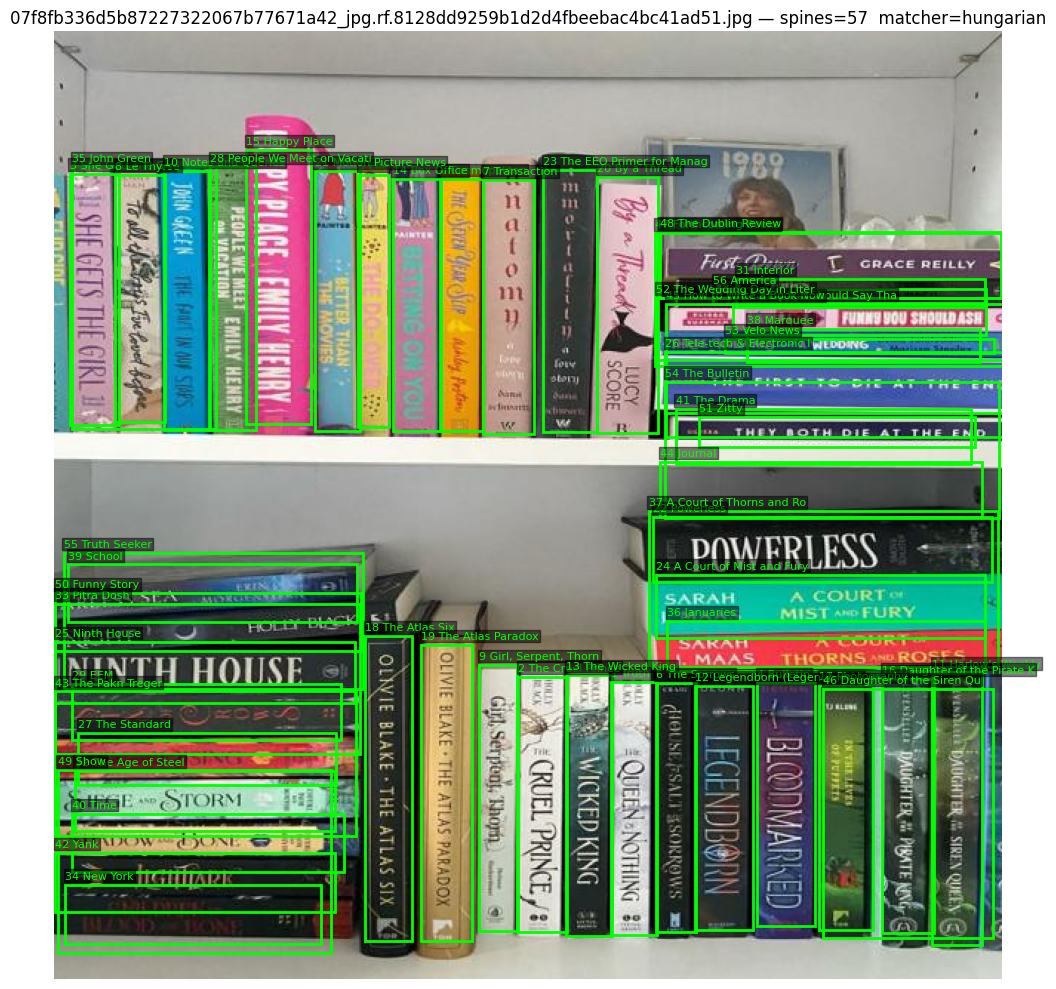

 #    det  ocr_conf    sim  ocr_text -> matched title / authors
 0  1.00      0.39   0.72  'apw 3md 0)'                             -> Cosmopolitan / 
 1  1.00      0.68   0.73  'QUEEN NOTHING o'                        -> Truth / 
 2  1.00      0.88   0.92  'CRUEL PRINCE HOLLY RUMK'                -> The Cruel Prince / Holly Black
 3  1.00      0.98   0.78  'THE GIRL SHE GETS'                      -> She Gets the Girl / Rachael Lippincott, Alyson Derri
 4  1.00      0.92   0.66  'BLODMARKEO'                             -> Bulletin / 
 5  1.00      0.74   0.88  'THE'                                    -> Elle / 
 6  1.00      0.92   0.63  'HOUSEFSALT SORROWS'                     -> The Sorrows / M. Earl Smith
 7  1.00      0.60   0.67  '=a- n 1) Tapy 10e1 Aana f W'            -> Transaction / 
 8  1.00      0.83   0.61  'all theLrys Iive lov 16'                -> Le Thyrse / 
 9  1.00      0.91   0.84  'Girl Se Serpent, Thorn'                 -> Girl, Serpent, Thorn / Melissa Bashardous

In [12]:
def visualize_pipeline(result: Dict, figsize=(12, 10)):
    with Image.open(result["image_path"]) as im:
        pil_img = im.convert("RGB")

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(np.asarray(pil_img))

    for i, r in enumerate(result["results"]):
        x1, y1, x2, y2 = r["bbox"]
        matched = r["match"] is not None
        color = "lime" if matched else "orange"
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 fill=False, edgecolor=color, linewidth=2)
        ax.add_patch(rect)
        label = f"{i}"
        if matched:
            label += f" {r['match']['title'][:24]}"
        ax.text(x1, max(0, y1 - 4), label, color=color, fontsize=8,
                bbox=dict(facecolor="black", alpha=0.5, pad=1))

    ax.set_title(f"{Path(result['image_path']).name} — spines={result['n_spines']}  matcher={result['matcher']}")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

    # print a table-ish summary
    print(f"{'#':>2}  {'det':>5}  {'ocr_conf':>8}  {'sim':>5}  ocr_text -> matched title / authors")
    for i, r in enumerate(result["results"]):
        ocr = r["ocr_text"][:40].replace("\n", " ")
        if r["match"] is None:
            print(f"{i:>2}  {r['det_score']:.2f}  {r['ocr_conf']:8.2f}  {'--':>5}  {ocr!r:40s} -> (no match)")
        else:
            m = r["match"]
            authors = ", ".join(m["authors"])[:32]
            print(f"{i:>2}  {r['det_score']:.2f}  {r['ocr_conf']:8.2f}  {m['similarity']:5.2f}  {ocr!r:40s} -> {m['title'][:40]} / {authors}")


valid_images = sorted([p for p in (DATA_DIR / "valid" / "images").iterdir()
                       if p.is_file() and p.suffix.lower() in IMAGE_EXTS])
sample_path = valid_images[0]
print("Processing:", sample_path)
result = process_shelf_image(sample_path, matcher="hungarian", sim_threshold=0.2)
visualize_pipeline(result)


## 8) Ablation experiments

Focused experiments for check-in 3. 

- **A. Rotation ablation**: `OCR_ROTATIONS = [0]` vs `[0, 90, 180, 270]`.
- **B. Matcher variant**: `matcher="argmax"` vs `matcher="hungarian"`.
- **C. Target-list size**: `gb_top_k = 5` vs `20` vs `40`.
- **D. Multimodal rerank**: `use_image_rerank=False` vs `True` (fuses CLIP text + CLIP cover-image similarity).
- **E. Fusion weight** (inside D): `alpha = 1.0` (text only), `0.5`, `0.0` (image only).


In [13]:
def summarize(result: Dict) -> Dict:
    n = result["n_spines"]
    with_ocr = sum(1 for r in result["results"] if r["ocr_text"])
    with_match = sum(1 for r in result["results"] if r["match"] is not None)
    return {
        "image": Path(result["image_path"]).name,
        "n_spines": n,
        "ocr_rate": with_ocr / max(1, n),
        "match_rate": with_match / max(1, n),
    }


def run_on_set(image_paths: List[Path], **kwargs) -> List[Dict]:
    rows = []
    for p in image_paths:
        res = process_shelf_image(p, **kwargs)
        rows.append(summarize(res))
    return rows


SAMPLE = valid_images[:5]

print("Argmax (text only), top_k=20")
rows_a = run_on_set(SAMPLE, matcher="argmax", sim_threshold=0.2, gb_top_k=20)
for r in rows_a:
    print(r)

print("\nHungarian (text only), top_k=20")
rows_h = run_on_set(SAMPLE, matcher="hungarian", sim_threshold=0.2, gb_top_k=20)
for r in rows_h:
    print(r)

print("\nHungarian (text + image rerank, alpha=0.5), top_k=20")
rows_m = run_on_set(SAMPLE, matcher="hungarian", sim_threshold=0.2, gb_top_k=20,
                    use_image_rerank=True, alpha=0.5)
for r in rows_m:
    print(r)


Argmax (text only), top_k=20


Resized image size (5731x320) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (320x5731) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (320x5731) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (320x5731) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (320x6496) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (6496x320) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (320x6496) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (6496x320) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (5883x320) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (5883x320) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (5883x320) exceeds max_side_limit of 4000. Resizing to fit wi

{'image': '07f8fb336d5b87227322067b77671a42_jpg.rf.8128dd9259b1d2d4fbeebac4bc41ad51.jpg', 'n_spines': 57, 'ocr_rate': 0.9298245614035088, 'match_rate': 1.0}
{'image': '0a9a11c2fcb949b2e39928b2463ec332_jpg.rf.94eaffe3f84fe4b9de0bd8135ee2e1c0.jpg', 'n_spines': 12, 'ocr_rate': 1.0, 'match_rate': 1.0}
{'image': '0badf1cde2d307a330380a8b5077982d_jpg.rf.3c430c896ca5334eae0b9ceecbe6fc92.jpg', 'n_spines': 14, 'ocr_rate': 0.7857142857142857, 'match_rate': 1.0}
{'image': '0dd5a7e424f221302e3e46d6121742d8_jpg.rf.9e0eb53f6e37e12c0453e87106e6bac2.jpg', 'n_spines': 46, 'ocr_rate': 0.8913043478260869, 'match_rate': 1.0}
{'image': '105166ea4cf31e33ecf3c40d7ea461f0_jpg.rf.24195fdf59f6f1abbc6f72bd453f266d.jpg', 'n_spines': 14, 'ocr_rate': 0.7857142857142857, 'match_rate': 1.0}

Hungarian (text only), top_k=20


Resized image size (5731x320) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (320x5731) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (320x5731) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (320x5731) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (320x6496) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (6496x320) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (320x6496) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (6496x320) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (5883x320) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (5883x320) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (5883x320) exceeds max_side_limit of 4000. Resizing to fit wi

{'image': '07f8fb336d5b87227322067b77671a42_jpg.rf.8128dd9259b1d2d4fbeebac4bc41ad51.jpg', 'n_spines': 57, 'ocr_rate': 0.9298245614035088, 'match_rate': 1.0}
{'image': '0a9a11c2fcb949b2e39928b2463ec332_jpg.rf.94eaffe3f84fe4b9de0bd8135ee2e1c0.jpg', 'n_spines': 12, 'ocr_rate': 1.0, 'match_rate': 1.0}
{'image': '0badf1cde2d307a330380a8b5077982d_jpg.rf.3c430c896ca5334eae0b9ceecbe6fc92.jpg', 'n_spines': 14, 'ocr_rate': 0.7857142857142857, 'match_rate': 1.0}
{'image': '0dd5a7e424f221302e3e46d6121742d8_jpg.rf.9e0eb53f6e37e12c0453e87106e6bac2.jpg', 'n_spines': 46, 'ocr_rate': 0.8913043478260869, 'match_rate': 1.0}
{'image': '105166ea4cf31e33ecf3c40d7ea461f0_jpg.rf.24195fdf59f6f1abbc6f72bd453f266d.jpg', 'n_spines': 14, 'ocr_rate': 0.7857142857142857, 'match_rate': 1.0}

Hungarian (text + image rerank, alpha=0.5), top_k=20


Resized image size (5731x320) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (320x5731) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (320x5731) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (320x5731) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (320x6496) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (6496x320) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (320x6496) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (6496x320) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (5883x320) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (5883x320) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (5883x320) exceeds max_side_limit of 4000. Resizing to fit wi

{'image': '07f8fb336d5b87227322067b77671a42_jpg.rf.8128dd9259b1d2d4fbeebac4bc41ad51.jpg', 'n_spines': 57, 'ocr_rate': 0.9298245614035088, 'match_rate': 1.0}
{'image': '0a9a11c2fcb949b2e39928b2463ec332_jpg.rf.94eaffe3f84fe4b9de0bd8135ee2e1c0.jpg', 'n_spines': 12, 'ocr_rate': 1.0, 'match_rate': 1.0}
{'image': '0badf1cde2d307a330380a8b5077982d_jpg.rf.3c430c896ca5334eae0b9ceecbe6fc92.jpg', 'n_spines': 14, 'ocr_rate': 0.7857142857142857, 'match_rate': 1.0}
{'image': '0dd5a7e424f221302e3e46d6121742d8_jpg.rf.9e0eb53f6e37e12c0453e87106e6bac2.jpg', 'n_spines': 46, 'ocr_rate': 0.8913043478260869, 'match_rate': 1.0}
{'image': '105166ea4cf31e33ecf3c40d7ea461f0_jpg.rf.24195fdf59f6f1abbc6f72bd453f266d.jpg', 'n_spines': 14, 'ocr_rate': 0.7857142857142857, 'match_rate': 1.0}


## 9) Matcher ablation + similarity-threshold sweep

Compares **Hungarian** vs **argmax** assignment across a range of similarity thresholds, using paddleocr. Argmax lets multiple spines map to the same book (collisions on series); Hungarian enforces one-to-one and should match-rate-win at equal threshold.

We run each image once and re-assign on the cached similarity matrix per `(matcher, sim_threshold)`


In [14]:
def _collect_spines_and_similarities(image_paths, backend="paddleocr", gb_top_k=GB_TOPK):
    """Run detect+OCR+GB+CLIP text sim once per image; return per-image state
    that can be re-matched under different matcher/threshold combinations."""
    per_image = []
    for p in image_paths:
        with Image.open(p) as im:
            pil_img = im.convert("RGB")
        spines = detect_spines(pil_img)
        for s in spines:
            s["ocr"] = ocr_spine(s["crop"], backend=backend)

        candidate_pool, seen = [], set()
        for s in spines:
            txt = s["ocr"]["text"]
            if not txt:
                continue
            for c in query_google_books(txt, top_k=gb_top_k):
                vid = c.get("volumeId")
                if vid and vid not in seen:
                    seen.add(vid)
                    candidate_pool.append(c)

        spine_texts = [s["ocr"]["text"] for s in spines]
        S_txt = build_similarity_matrix(spine_texts, candidate_pool)
        per_image.append({
            "path": p, "spines": spines,
            "candidates": candidate_pool, "S_txt": S_txt,
        })
    return per_image


def matcher_threshold_sweep(per_image, matchers=("hungarian", "argmax"),
                            thresholds=(0.15, 0.20, 0.25, 0.30, 0.35)):
    rows = []
    for m in matchers:
        assign_fn = hungarian_assign if m == "hungarian" else argmax_assign
        for th in thresholds:
            match_flags, sims, unique_titles = [], [], []
            for state in per_image:
                S = state["S_txt"]
                n_sp = len(state["spines"])
                pairs = assign_fn(S, sim_threshold=th)
                matched_set = {r: (c, sim) for r, c, sim in pairs}
                titles_this_img = []
                for i in range(n_sp):
                    if i in matched_set:
                        c_idx, sim = matched_set[i]
                        match_flags.append(1)
                        sims.append(sim)
                        titles_this_img.append(state["candidates"][c_idx].get("title", ""))
                    else:
                        match_flags.append(0)
                unique_titles.append(len(set(t for t in titles_this_img if t)))
            rows.append({
                "matcher": m,
                "threshold": th,
                "n_spines": len(match_flags),
                "match_rate": round(float(np.mean(match_flags)) if match_flags else 0.0, 3),
                "avg_sim": round(float(np.mean(sims)) if sims else 0.0, 3),
                "avg_unique_titles_per_img": round(float(np.mean(unique_titles)) if unique_titles else 0.0, 2),
            })
    return rows


SAMPLE_SWEEP = valid_images[:5]
print(f"Caching spine state + text sim for {len(SAMPLE_SWEEP)} images (OCR backend=paddleocr)...")
_swept_state = _collect_spines_and_similarities(SAMPLE_SWEEP, backend="paddleocr")

sweep_rows = matcher_threshold_sweep(_swept_state)
hdr = ["matcher", "threshold", "n_spines", "match_rate", "avg_sim", "avg_unique_titles_per_img"]
print("\n" + "  ".join(f"{h:>26s}" for h in hdr))
for row in sweep_rows:
    print("  ".join(f"{str(row[h]):>26s}" for h in hdr))


Caching spine state + text sim for 5 images (OCR backend=paddleocr)...


Resized image size (5731x320) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (320x5731) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (320x5731) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (320x5731) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (320x6496) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (6496x320) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (320x6496) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (6496x320) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (5883x320) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (5883x320) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (5883x320) exceeds max_side_limit of 4000. Resizing to fit wi


                   matcher                   threshold                    n_spines                  match_rate                     avg_sim   avg_unique_titles_per_img
                 hungarian                        0.15                         143                         1.0                       0.718                        26.2
                 hungarian                         0.2                         143                         1.0                       0.718                        26.2
                 hungarian                        0.25                         143                         1.0                       0.718                        26.2
                 hungarian                         0.3                         143                         1.0                       0.718                        26.2
                 hungarian                        0.35                         143                         1.0                       0.718                        26

## 10) Multimodal fusion ablation — alpha sweep

Sweeps `alpha` in `S_fused = alpha * S_txt + (1-alpha) * S_img`:

- `alpha = 1.0` → text-only (baseline from §5)
- `alpha = 0.0` → image-only (CLIP spine crop vs cover thumbnail)
- Anything in between tests whether cover images actually add signal on top of OCR text.

Done with Hungarian matching at a fixed `sim_threshold`.


In [15]:
def alpha_sweep(per_image, alphas=(1.0, 0.75, 0.5, 0.25, 0.0), sim_threshold=0.2):
    # Pre-compute S_img per image so we don't re-download thumbnails for each alpha.
    for state in per_image:
        if "S_img" not in state:
            state["S_img"] = build_image_similarity_matrix(
                [s["crop"] for s in state["spines"]], state["candidates"]
            )

    rows = []
    for a in alphas:
        match_flags, sims = [], []
        for state in per_image:
            S = fuse_similarities(state["S_txt"], state["S_img"], alpha=a)
            pairs = hungarian_assign(S, sim_threshold=sim_threshold)
            matched_set = {r: (c, sim) for r, c, sim in pairs}
            for i in range(len(state["spines"])):
                if i in matched_set:
                    match_flags.append(1)
                    sims.append(matched_set[i][1])
                else:
                    match_flags.append(0)
        rows.append({
            "alpha": a,
            "n_spines": len(match_flags),
            "match_rate": round(float(np.mean(match_flags)) if match_flags else 0.0, 3),
            "avg_sim": round(float(np.mean(sims)) if sims else 0.0, 3),
        })
    return rows


alpha_rows = alpha_sweep(_swept_state)
hdr = ["alpha", "n_spines", "match_rate", "avg_sim"]
print("  ".join(f"{h:>12s}" for h in hdr))
for row in alpha_rows:
    print("  ".join(f"{str(row[h]):>12s}" for h in hdr))

       alpha      n_spines    match_rate       avg_sim
         1.0           143           1.0         0.718
        0.75           143           1.0         0.623
         0.5           143           1.0         0.559
        0.25           143           1.0         0.535
         0.0           143           1.0         0.542


## OCR backend ablation testing

### - EasyOCR: classic CRNN baseline
### - PaddleOCR: newer CRNN
### - TrOCR: whole-crop transformer OCR
### - TrOCR-Paddle Hybrid: Paddle detect + TrOCR-recognize
### - Florence 2: VLM-style OCR

Runs the full pipeline on a small image set with each backend and prints:
- **n_images** : number of shelf images evaluated
- **n_spines** : total number of detected spine crops across those images
- **sec_total** : seconds for the whole backend run (detection + OCR + retrieval + match)
- **sec_per_image** : `sec_total / n_images`, the headline latency number
- **nonempty_rate** : fraction of spines for which OCR returned any non-empty text (coverage / OCR recall)
- **avg_chars** : average kept-token character count per spine
- **avg_conf**  : average OCR confidence on kept tokens
- **match_rate** : fraction of spines that got a Google Books match at the given `sim_threshold`
- **avg_sim** : average CLIP similarity on matched spines

Higher `match_rate` and `avg_sim` at the same `sim_threshold` indicate cleaner OCR feeding the retrieval and matcher


We treat **PaddleOCR** as the strong baseline and compare it to the other OCR models. This is a controlled swap: detection, preprocessing, rotation sweep, Google Books retrieval, CLIP similarity, and Hungarian matching are held constant.

In [9]:
def run_ocr_backend_ablation(image_paths, backends=("easyocr", "paddleocr", "trocr", "trocr_hybrid", "florence"),
                            matcher="hungarian", sim_threshold=0.2,
                            gb_top_k=GB_TOPK,
                            use_image_rerank=False, alpha=1.0):
    rows = []
    for b in backends:
        t0 = time.time()
        all_chars, all_conf, all_sims, all_matches, all_nonempty, n_spines = [], [], [], [], [], 0
        for p in image_paths:
            out = process_shelf_image(
                p,
                matcher=matcher,
                sim_threshold=sim_threshold,
                gb_top_k=gb_top_k,
                use_image_rerank=use_image_rerank,
                alpha=alpha,
                ocr_backend=b,
            )
            for r in out["results"]:
                n_spines += 1
                txt = r.get("ocr_text", "") or ""
                all_chars.append(len(txt))
                all_nonempty.append(1 if txt.strip() else 0)
                all_conf.append(float(r.get("ocr_conf", 0.0)))
                if r.get("match") is not None:
                    all_matches.append(1)
                    all_sims.append(float(r["match"].get("similarity", 0.0)))
                else:
                    all_matches.append(0)

        dt = time.time() - t0
        rows.append({
            "backend": b,
            "n_images": len(image_paths),
            "n_spines": n_spines,
            "sec_total": round(dt, 1),
            "sec_per_image": round(dt / max(1, len(image_paths)), 2),
            "nonempty_rate": round(float(np.mean(all_nonempty)) if all_nonempty else 0.0, 3),
            "avg_chars": round(float(np.mean(all_chars)) if all_chars else 0.0, 2),
            "avg_conf": round(float(np.mean(all_conf)) if all_conf else 0.0, 3),
            "match_rate": round(float(np.mean(all_matches)) if all_matches else 0.0, 3),
            "avg_sim": round(float(np.mean(all_sims)) if all_sims else 0.0, 3),
        })
    return rows
    
valid_images = sorted([p for p in (DATA_DIR / "valid" / "images").iterdir()
                       if p.is_file() and p.suffix.lower() in IMAGE_EXTS])

ABLATION_IMAGES = valid_images[:3]
print(f"Running OCR backend ablation on {len(ABLATION_IMAGES)} images... (first run may download model weights)")
rows = run_ocr_backend_ablation(
    ABLATION_IMAGES,
    backends=("easyocr", "paddleocr", "trocr", "trocr_hybrid", "florence"),
)

hdr = ["backend", "n_images", "n_spines", "sec_total", "sec_per_image",
       "nonempty_rate", "avg_chars", "avg_conf", "match_rate", "avg_sim"]
print("\n" + "  ".join(f"{h:>13s}" for h in hdr))
for r in rows:
    print("  ".join(f"{str(r[h]):>13s}" for h in hdr))


Running OCR backend ablation on 3 images... (first run may download model weights)


/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/paddle/utils/cpp_extension/extension_utils.py:715: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/eyoon/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/eyoon/.paddlex/official_models/UVDoc`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redow


      backend       n_images       n_spines      sec_total  sec_per_image  nonempty_rate      avg_chars       avg_conf     match_rate        avg_sim
      easyocr              3             83           27.3            9.1          0.904           7.41          0.601            1.0          0.608
    paddleocr              3             83           27.0           8.99          0.916          24.22          0.751            1.0           0.72
        trocr              3             83           42.9           14.3            1.0          17.61          0.637            1.0          0.645
 trocr_hybrid              3             83           54.1          18.03            1.0          22.46          0.733            1.0          0.665
     florence              3             83          106.9          35.63            1.0          17.75            1.0            1.0          0.685


## Qwen2-VL-2B

In [14]:
# --- Qwen2-VL-2B OCR backend (plug-in, does not modify cell 7) ---
_qwen2vl = None
QWEN2VL_MODEL_NAME = "Qwen/Qwen2-VL-2B-Instruct"

# SPEED KNOBS
QWEN2VL_MIN_PIXELS = 4 * 28 * 28
QWEN2VL_MAX_PIXELS = 256 * 28 * 28
QWEN2VL_MAX_NEW_TOKENS = 48
QWEN2VL_ROTATIONS = [0]

QWEN2VL_OCR_PROMPT = (
    "This image shows ONE book spine. Read every text line visible on it. "
    "Transcribe lines in top-to-bottom reading order, one line per output row, "
    "separated by a single newline. Preserve the exact wording — do not paraphrase, "
    "translate, reorder, or invent words. Do not add quotes, labels, or "
    "explanations. If a line is unreadable, skip it. Output only the transcription."
)


def _get_qwen2vl(model_name: str = QWEN2VL_MODEL_NAME):
    global _qwen2vl
    if _qwen2vl is None:
        from transformers import AutoProcessor, Qwen2VLForConditionalGeneration

        torch_dtype = torch.float16 if device.type == "cuda" else torch.float32
        target = "cuda:0" if device.type == "cuda" else "cpu"

        proc = AutoProcessor.from_pretrained(
            model_name,
            trust_remote_code=True,
            min_pixels=QWEN2VL_MIN_PIXELS,
            max_pixels=QWEN2VL_MAX_PIXELS,
        )
        mdl = Qwen2VLForConditionalGeneration.from_pretrained(
            model_name,
            torch_dtype=torch_dtype,
            device_map={"": target},
            trust_remote_code=True,
        )
        leftovers = _materialize_meta_tensors(mdl, torch.device(target), torch_dtype)
        if leftovers:
            print(f"[qwen2vl] materialized {leftovers} leftover meta tensors -> {target}")
        mdl.eval()
        _qwen2vl = {"processor": proc, "model": mdl, "name": model_name,
                    "device": target, "dtype": torch_dtype}
    return _qwen2vl


def _qwen2vl_tokens(arr: np.ndarray,
                    model_name: str = QWEN2VL_MODEL_NAME,
                    max_new_tokens: int = QWEN2VL_MAX_NEW_TOKENS) -> List[Tuple[str, float]]:
    bundle = _get_qwen2vl(model_name)
    proc, mdl = bundle["processor"], bundle["model"]
    mdl_device = bundle["device"]
    mdl_dtype = bundle["dtype"]

    pil = Image.fromarray(arr) if not isinstance(arr, Image.Image) else arr

    messages = [{
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": QWEN2VL_OCR_PROMPT},
        ],
    }]
    chat_text = proc.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    inputs = proc(text=[chat_text], images=[pil], padding=True, return_tensors="pt")
    moved = {}
    for k, v in inputs.items():
        if not isinstance(v, torch.Tensor):
            moved[k] = v
            continue
        v = v.to(mdl_device)
        if v.is_floating_point():
            v = v.to(mdl_dtype)
        moved[k] = v
    inputs = moved

    with torch.no_grad():
        gen_ids = mdl.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)

    trimmed = [out[len(inp):] for inp, out in zip(inputs["input_ids"], gen_ids)]
    raw = proc.batch_decode(trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]

    lines = [ln.strip(" \t\"'`") for ln in str(raw).splitlines()]
    lines = [ln for ln in lines if ln and ln.lower() not in {"none", "n/a", "unreadable"}]
    deduped: List[str] = []
    for ln in lines:
        if not deduped or deduped[-1].lower() != ln.lower():
            deduped.append(ln)
    return [(ln, 1.0) for ln in deduped]


# --- Safe idempotent monkey-patch of _ocr_tokens ---
# Only capture the ORIGINAL (un-wrapped) dispatcher once, no matter how many
# times this cell is re-run. Detects prior wrapping via a sentinel attribute.
if not getattr(_ocr_tokens, "_qwen_wrapped", False):
    _ORIG_OCR_TOKENS = _ocr_tokens
else:
    # _ocr_tokens is already a wrapper from a previous run of this cell;
    # _ORIG_OCR_TOKENS still points at the true original.
    pass


def _ocr_tokens(arr: np.ndarray, backend: str) -> List[Tuple[str, float]]:
    if backend == "qwen2vl":
        return _qwen2vl_tokens(arr)
    return _ORIG_OCR_TOKENS(arr, backend)


_ocr_tokens._qwen_wrapped = True


# --- Ablation (single rotation for speed) ---
ABLATION_IMAGES = valid_images[:3]
print(f"Running Qwen2-VL ablation on {len(ABLATION_IMAGES)} images "
      f"(rotations={QWEN2VL_ROTATIONS}, max_pixels={QWEN2VL_MAX_PIXELS})...\n")

t0 = time.time()
rows_qwen = []
for b in ("paddleocr", "qwen2vl"):
    rotations = QWEN2VL_ROTATIONS if b == "qwen2vl" else OCR_ROTATIONS
    _saved_rots = OCR_ROTATIONS
    OCR_ROTATIONS = rotations
    try:
        rows_qwen += run_ocr_backend_ablation(ABLATION_IMAGES, backends=(b,))
    finally:
        OCR_ROTATIONS = _saved_rots

dt = time.time() - t0
print(f"\nTotal wall time: {dt:.1f}s")

hdr = ["backend", "n_images", "n_spines", "sec_total", "sec_per_image",
       "nonempty_rate", "avg_chars", "avg_conf", "match_rate", "avg_sim"]
print("\n" + "  ".join(f"{h:>13s}" for h in hdr))
for r in rows_qwen:
    print("  ".join(f"{str(r[h]):>13s}" for h in hdr))


Running Qwen2-VL ablation on 3 images (rotations=[0], max_pixels=200704)...



The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
Loading checkpoint shards: 100%|██████████| 2/2 [00:11<00:00,  5.99s/it]



Total wall time: 254.8s

      backend       n_images       n_spines      sec_total  sec_per_image  nonempty_rate      avg_chars       avg_conf     match_rate        avg_sim
    paddleocr              3             83           34.3          11.44          0.916          24.22          0.751            1.0           0.72
      qwen2vl              3             83          220.5           73.5            1.0          31.47            1.0            1.0          0.796


## Qwen2.5-VL-3B

Adds the newer, larger **Qwen2.5-VL-3B-Instruct** VLM as backend `qwen25vl`.
Same prompt, same pixel caps, same plug-in pattern as cell 35 — only the
model class and weights differ.

First run downloads ~7 GB.

In [16]:
# Free 2B to make room for 3B
del _qwen2vl
_qwen2vl = None
import gc; gc.collect()
torch.cuda.empty_cache()
print(f"free VRAM now: {(torch.cuda.mem_get_info()[0]/1e9):.2f} GB")

free VRAM now: 0.00 GB


In [18]:
# --- Qwen2.5-VL-3B OCR backend (plug-in) ---
_qwen25vl = None
QWEN25VL_MODEL_NAME = "Qwen/Qwen2.5-VL-3B-Instruct"

# Reuse the tuned knobs from cell 35.
QWEN25VL_MIN_PIXELS = QWEN2VL_MIN_PIXELS
QWEN25VL_MAX_PIXELS = QWEN2VL_MAX_PIXELS
QWEN25VL_MAX_NEW_TOKENS = QWEN2VL_MAX_NEW_TOKENS
QWEN25VL_ROTATIONS = QWEN2VL_ROTATIONS
QWEN25VL_OCR_PROMPT = QWEN2VL_OCR_PROMPT


def _get_qwen25vl(model_name: str = QWEN25VL_MODEL_NAME):
    global _qwen25vl
    if _qwen25vl is None:
        from transformers import AutoProcessor
        try:
            from transformers import Qwen2_5_VLForConditionalGeneration as _QwenCls
        except ImportError:
            from transformers import AutoModelForImageTextToText as _QwenCls

        torch_dtype = torch.float16 if device.type == "cuda" else torch.float32
        target = "cuda:0" if device.type == "cuda" else "cpu"

        proc = AutoProcessor.from_pretrained(
            model_name,
            trust_remote_code=True,
            min_pixels=QWEN25VL_MIN_PIXELS,
            max_pixels=QWEN25VL_MAX_PIXELS,
        )
        mdl = _QwenCls.from_pretrained(
            model_name,
            torch_dtype=torch_dtype,
            device_map={"": target},
            trust_remote_code=True,
        )
        leftovers = _materialize_meta_tensors(mdl, torch.device(target), torch_dtype)
        if leftovers:
            print(f"[qwen25vl] materialized {leftovers} leftover meta tensors -> {target}")
        mdl.eval()
        _qwen25vl = {"processor": proc, "model": mdl, "name": model_name,
                     "device": target, "dtype": torch_dtype}
    return _qwen25vl


def _qwen25vl_tokens(arr: np.ndarray,
                     model_name: str = QWEN25VL_MODEL_NAME,
                     max_new_tokens: int = QWEN25VL_MAX_NEW_TOKENS) -> List[Tuple[str, float]]:
    bundle = _get_qwen25vl(model_name)
    proc, mdl = bundle["processor"], bundle["model"]
    mdl_device = bundle["device"]
    mdl_dtype = bundle["dtype"]

    pil = Image.fromarray(arr) if not isinstance(arr, Image.Image) else arr

    messages = [{
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": QWEN25VL_OCR_PROMPT},
        ],
    }]
    chat_text = proc.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    inputs = proc(text=[chat_text], images=[pil], padding=True, return_tensors="pt")
    moved = {}
    for k, v in inputs.items():
        if not isinstance(v, torch.Tensor):
            moved[k] = v
            continue
        v = v.to(mdl_device)
        if v.is_floating_point():
            v = v.to(mdl_dtype)
        moved[k] = v
    inputs = moved

    with torch.no_grad():
        gen_ids = mdl.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)

    trimmed = [out[len(inp):] for inp, out in zip(inputs["input_ids"], gen_ids)]
    raw = proc.batch_decode(trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]

    lines = [ln.strip(" \t\"'`") for ln in str(raw).splitlines()]
    lines = [ln for ln in lines if ln and ln.lower() not in {"none", "n/a", "unreadable"}]
    deduped: List[str] = []
    for ln in lines:
        if not deduped or deduped[-1].lower() != ln.lower():
            deduped.append(ln)
    return [(ln, 1.0) for ln in deduped]


if not getattr(_ocr_tokens, "_qwen25_wrapped", False):
    _PREV_OCR_TOKENS = _ocr_tokens


def _ocr_tokens(arr: np.ndarray, backend: str) -> List[Tuple[str, float]]:
    if backend == "qwen25vl":
        return _qwen25vl_tokens(arr)
    return _PREV_OCR_TOKENS(arr, backend)


_ocr_tokens._qwen_wrapped = True
_ocr_tokens._qwen25_wrapped = True


# --- Ablation: Qwen2.5-VL-3B only (2B has been freed; paddleocr already benchmarked) ---
ABLATION_IMAGES = valid_images[:3]
print(f"Running Qwen2.5-VL-3B ablation on {len(ABLATION_IMAGES)} images "
      f"(rotations={QWEN25VL_ROTATIONS}, max_pixels={QWEN25VL_MAX_PIXELS})...")
print("(first call downloads ~7 GB of Qwen2.5-VL-3B weights)\n")

t0 = time.time()
rows_q25 = []
BACKENDS_TO_RUN = ("paddleocr", "qwen25vl")   # ← real tuple, trailing comma not needed for 2+ items
for b in BACKENDS_TO_RUN:
    rotations = [0] if b == "qwen25vl" else OCR_ROTATIONS
    _saved_rots = OCR_ROTATIONS
    OCR_ROTATIONS = rotations
    try:
        rows_q25 += run_ocr_backend_ablation(ABLATION_IMAGES, backends=(b,))
    finally:
        OCR_ROTATIONS = _saved_rots

dt = time.time() - t0
print(f"\nTotal wall time: {dt:.1f}s")

hdr = ["backend", "n_images", "n_spines", "sec_total", "sec_per_image",
       "nonempty_rate", "avg_chars", "avg_conf", "match_rate", "avg_sim"]
print("\n" + "  ".join(f"{h:>13s}" for h in hdr))
for r in rows_q25:
    print("  ".join(f"{str(r[h]):>13s}" for h in hdr))


Running Qwen2.5-VL-3B ablation on 3 images (rotations=[0], max_pixels=200704)...
(first call downloads ~7 GB of Qwen2.5-VL-3B weights)



The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
Loading checkpoint shards: 100%|██████████| 2/2 [00:05<00:00,  2.70s/it]



Total wall time: 864.1s

      backend       n_images       n_spines      sec_total  sec_per_image  nonempty_rate      avg_chars       avg_conf     match_rate        avg_sim
    paddleocr              3             83           28.7           9.58          0.916          24.22          0.751            1.0           0.72
     qwen25vl              3             83          835.4         278.45            1.0          35.54            1.0            1.0          0.764


In [19]:
del _qwen25vl
_qwen25vl = None
import gc; gc.collect()
torch.cuda.empty_cache()
print(f"free VRAM: {torch.cuda.mem_get_info()[0]/1e9:.2f} GB")

free VRAM: 7.84 GB


## InternVL2.5-2B

Same parameter class as Qwen2-VL-2B (2B) for a direct comparison. Uses a
custom `.chat()` API with ImageNet-normalized 448×448 tiling. For spine
crops we keep a single tile (no dynamic multi-tile) since spines are
low-resolution and narrow — extra tiles mostly duplicate info and cost time.

In [21]:
# --- InternVL2.5-2B OCR backend (plug-in) ---
_internvl = None
INTERNVL_MODEL_NAME = "OpenGVLab/InternVL2_5-2B"
INTERNVL_IMG_SIZE = 448
INTERNVL_MAX_NEW_TOKENS = 64
INTERNVL_ROTATIONS = [0]
INTERNVL_OCR_PROMPT = (
    "<image>\nThis image shows ONE book spine. Read every text line visible. "
    "Output each line on its own row, top-to-bottom, preserving exact wording. "
    "No quotes, no commentary, only the transcription."
)

# ImageNet normalization used by InternVL's visual encoder.
_INTERNVL_MEAN = (0.485, 0.456, 0.406)
_INTERNVL_STD = (0.229, 0.224, 0.225)


def _internvl_preprocess(pil_img: Image.Image, size: int = INTERNVL_IMG_SIZE) -> torch.Tensor:
    """Single-tile preprocessing: resize to square, ImageNet normalize.
    Returns a [1, 3, size, size] tensor."""
    import torchvision.transforms as T
    from torchvision.transforms.functional import InterpolationMode

    if pil_img.mode != "RGB":
        pil_img = pil_img.convert("RGB")
    tfm = T.Compose([
        T.Resize((size, size), interpolation=InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(mean=_INTERNVL_MEAN, std=_INTERNVL_STD),
    ])
    return tfm(pil_img).unsqueeze(0)


def _get_internvl(model_name: str = INTERNVL_MODEL_NAME):
    global _internvl
    if _internvl is None:
        from transformers import AutoModel, AutoTokenizer

        torch_dtype = torch.bfloat16 if device.type == "cuda" else torch.float32
        target = "cuda:0" if device.type == "cuda" else "cpu"

        tok = AutoTokenizer.from_pretrained(
            model_name, trust_remote_code=True, use_fast=False
        )
        mdl = AutoModel.from_pretrained(
            model_name,
            torch_dtype=torch_dtype,
            trust_remote_code=True,
            low_cpu_mem_usage=True,
        ).to(target).eval()

        _internvl = {"tokenizer": tok, "model": mdl, "name": model_name,
                     "device": target, "dtype": torch_dtype}
    return _internvl


def _internvl_tokens(arr: np.ndarray,
                     model_name: str = INTERNVL_MODEL_NAME,
                     max_new_tokens: int = INTERNVL_MAX_NEW_TOKENS) -> List[Tuple[str, float]]:
    bundle = _get_internvl(model_name)
    tok, mdl = bundle["tokenizer"], bundle["model"]
    mdl_device = bundle["device"]
    mdl_dtype = bundle["dtype"]

    pil = Image.fromarray(arr) if not isinstance(arr, Image.Image) else arr
    pixel_values = _internvl_preprocess(pil).to(dtype=mdl_dtype, device=mdl_device)

    generation_config = dict(max_new_tokens=max_new_tokens, do_sample=False)
    with torch.inference_mode():
        response = mdl.chat(tok, pixel_values, INTERNVL_OCR_PROMPT, generation_config)

    text = str(response)
    lines = [ln.strip(" \t\"'`*#|") for ln in text.splitlines()]
    lines = [ln for ln in lines if ln and ln.lower() not in {"none", "n/a", "unreadable"}]
    deduped: List[str] = []
    for ln in lines:
        if not deduped or deduped[-1].lower() != ln.lower():
            deduped.append(ln)
    return [(ln, 1.0) for ln in deduped]


# Chain another layer onto the dispatcher; idempotent via sentinel.
if not getattr(_ocr_tokens, "_internvl_wrapped", False):
    _PREV3_OCR_TOKENS = _ocr_tokens


def _ocr_tokens(arr: np.ndarray, backend: str) -> List[Tuple[str, float]]:
    if backend == "internvl":
        return _internvl_tokens(arr)
    return _PREV3_OCR_TOKENS(arr, backend)


_ocr_tokens._qwen_wrapped = True
_ocr_tokens._qwen25_wrapped = True
_ocr_tokens._paddlevl_wrapped = True
_ocr_tokens._internvl_wrapped = True


# --- Ablation: InternVL2.5-2B vs PaddleOCR ---
ABLATION_IMAGES = valid_images[:3]
print(f"Running InternVL2.5-2B ablation on {len(ABLATION_IMAGES)} images "
      f"(rotations={INTERNVL_ROTATIONS}, img_size={INTERNVL_IMG_SIZE})...")
print("(first call downloads ~4.5 GB of InternVL2.5-2B weights)\n")

t0 = time.time()
rows_iv = []
BACKENDS_TO_RUN = ("paddleocr", "internvl")
for b in BACKENDS_TO_RUN:
    rotations = [0] if b == "internvl" else OCR_ROTATIONS
    _saved_rots = OCR_ROTATIONS
    OCR_ROTATIONS = rotations
    try:
        rows_iv += run_ocr_backend_ablation(ABLATION_IMAGES, backends=(b,))
    finally:
        OCR_ROTATIONS = _saved_rots

dt = time.time() - t0
print(f"\nTotal wall time: {dt:.1f}s")

hdr = ["backend", "n_images", "n_spines", "sec_total", "sec_per_image",
       "nonempty_rate", "avg_chars", "avg_conf", "match_rate", "avg_sim"]
print("\n" + "  ".join(f"{h:>13s}" for h in hdr))
for r in rows_iv:
    print("  ".join(f"{str(r[h]):>13s}" for h in hdr))


Running InternVL2.5-2B ablation on 3 images (rotations=[0], img_size=448)...
(first call downloads ~4.5 GB of InternVL2.5-2B weights)



A new version of the following files was downloaded from https://huggingface.co/OpenGVLab/InternVL2_5-2B:
- tokenization_internlm2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/OpenGVLab/InternVL2_5-2B:
- configuration_intern_vit.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/OpenGVLab/InternVL2_5-2B:
- configuration_internlm2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/OpenGVLab/InternVL2_5-2B:
- configuration_internvl_chat.py
- conf

FlashAttention2 is not installed.


InternLM2ForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.



Total wall time: 308.4s

      backend       n_images       n_spines      sec_total  sec_per_image  nonempty_rate      avg_chars       avg_conf     match_rate        avg_sim
    paddleocr              3             83           22.2           7.39          0.916          24.22          0.751            1.0           0.72
     internvl              3             83          286.2           95.4            1.0          43.89            1.0            1.0          0.719


In [22]:
for name in ("_qwen2vl", "_qwen25vl", "_internvl"):
    if name in globals() and globals()[name] is not None:
        globals()[name] = None
import gc; gc.collect()
torch.cuda.empty_cache()
print(f"free VRAM: {torch.cuda.mem_get_info()[0]/1e9:.2f} GB")

free VRAM: 7.83 GB


## Nanonets-OCR2-3B

Nanonets-OCR2-3B is an OCR-specialized **finetune of Qwen2.5-VL-3B**. Same
architecture, same processor API, different weights (trained heavily on
document/markdown OCR). This lets us directly measure the effect of
OCR-specific finetuning vs the generalist Qwen2.5-VL-3B we already have.

In [24]:
# --- Nanonets-OCR2-3B OCR backend (plug-in) ---
_nanonets = None
NANONETS_MODEL_NAME = "nanonets/Nanonets-OCR2-3B"

# Reuse the same pixel caps / rotations as Qwen2.5-VL-3B (same base arch).
NANONETS_MIN_PIXELS = QWEN25VL_MIN_PIXELS
NANONETS_MAX_PIXELS = QWEN25VL_MAX_PIXELS
NANONETS_MAX_NEW_TOKENS = QWEN25VL_MAX_NEW_TOKENS
NANONETS_ROTATIONS = QWEN25VL_ROTATIONS
NANONETS_OCR_PROMPT = QWEN25VL_OCR_PROMPT


def _fix_qwen25vl_nested_text_config(cfg):
    """Nanonets-OCR2-3B's config.json stores text_config as a raw dict.
    Older transformers builds expect it to already be a PretrainedConfig
    instance; when it's a dict, GenerationConfig.from_model_config crashes
    with: 'dict' object has no attribute 'to_dict'. Promote it in-place."""
    tc = getattr(cfg, "text_config", None)
    if isinstance(tc, dict):
        # Try the dedicated text-config class first; fall back to the
        # parent VL config class (flat params) if not available.
        try:
            from transformers.models.qwen2_5_vl.configuration_qwen2_5_vl import (
                Qwen2_5_VLTextConfig as _TC,
            )
        except Exception:
            try:
                from transformers import Qwen2_5_VLConfig as _TC
            except Exception:
                from transformers import PretrainedConfig as _TC
        cfg.text_config = _TC(**tc)
    return cfg


def _get_nanonets(model_name: str = NANONETS_MODEL_NAME):
    global _nanonets
    if _nanonets is None:
        from transformers import AutoConfig, AutoProcessor, AutoModelForImageTextToText

        torch_dtype = torch.bfloat16 if device.type == "cuda" else torch.float32
        target = "cuda:0" if device.type == "cuda" else "cpu"

        cfg = AutoConfig.from_pretrained(model_name, trust_remote_code=True)
        cfg = _fix_qwen25vl_nested_text_config(cfg)

        proc = AutoProcessor.from_pretrained(
            model_name,
            trust_remote_code=True,
            min_pixels=NANONETS_MIN_PIXELS,
            max_pixels=NANONETS_MAX_PIXELS,
        )
        mdl = AutoModelForImageTextToText.from_pretrained(
            model_name,
            config=cfg,
            torch_dtype=torch_dtype,
            device_map={"": target},
            trust_remote_code=True,
        )
        leftovers = _materialize_meta_tensors(mdl, torch.device(target), torch_dtype)
        if leftovers:
            print(f"[nanonets] materialized {leftovers} leftover meta tensors -> {target}")
        mdl.eval()
        _nanonets = {"processor": proc, "model": mdl, "name": model_name,
                     "device": target, "dtype": torch_dtype}
    return _nanonets


def _nanonets_tokens(arr: np.ndarray,
                     model_name: str = NANONETS_MODEL_NAME,
                     max_new_tokens: int = NANONETS_MAX_NEW_TOKENS) -> List[Tuple[str, float]]:
    bundle = _get_nanonets(model_name)
    proc, mdl = bundle["processor"], bundle["model"]
    mdl_device = bundle["device"]
    mdl_dtype = bundle["dtype"]

    pil = Image.fromarray(arr) if not isinstance(arr, Image.Image) else arr
    if pil.mode != "RGB":
        pil = pil.convert("RGB")

    messages = [
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": NANONETS_OCR_PROMPT},
        ]},
    ]
    chat_text = proc.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    inputs = proc(text=[chat_text], images=[pil], padding=True, return_tensors="pt")
    moved = {}
    for k, v in inputs.items():
        if not isinstance(v, torch.Tensor):
            moved[k] = v
            continue
        v = v.to(mdl_device)
        if v.is_floating_point():
            v = v.to(mdl_dtype)
        moved[k] = v
    inputs = moved

    with torch.no_grad():
        gen_ids = mdl.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)

    trimmed = [out[len(inp):] for inp, out in zip(inputs["input_ids"], gen_ids)]
    raw = proc.batch_decode(trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]

    text = str(raw)
    for tag in ("<img>", "</img>", "<watermark>", "</watermark>",
                "<page_number>", "</page_number>", "<table>", "</table>",
                "<tr>", "</tr>", "<td>", "</td>", "<p>", "</p>"):
        text = text.replace(tag, " ")
    text = text.replace("$$", " ").replace("\\n", "\n")

    lines = [ln.strip(" \t\"'`*#|") for ln in text.splitlines()]
    lines = [ln for ln in lines if ln and ln.lower() not in {"none", "n/a", "unreadable"}]
    deduped: List[str] = []
    for ln in lines:
        if not deduped or deduped[-1].lower() != ln.lower():
            deduped.append(ln)
    return [(ln, 1.0) for ln in deduped]


# Chain another layer onto the dispatcher; idempotent via sentinel.
if not getattr(_ocr_tokens, "_nanonets_wrapped", False):
    _PREV4_OCR_TOKENS = _ocr_tokens


def _ocr_tokens(arr: np.ndarray, backend: str) -> List[Tuple[str, float]]:
    if backend == "nanonets":
        return _nanonets_tokens(arr)
    return _PREV4_OCR_TOKENS(arr, backend)


_ocr_tokens._qwen_wrapped = True
_ocr_tokens._qwen25_wrapped = True
_ocr_tokens._paddlevl_wrapped = True
_ocr_tokens._internvl_wrapped = True
_ocr_tokens._nanonets_wrapped = True


# Force-reload the bundle if a prior run half-initialized it.
_nanonets = None


# --- Ablation: Nanonets-OCR2-3B vs PaddleOCR ---
ABLATION_IMAGES = valid_images[:3]
print(f"Running Nanonets-OCR2-3B ablation on {len(ABLATION_IMAGES)} images "
      f"(rotations={NANONETS_ROTATIONS}, max_pixels={NANONETS_MAX_PIXELS})...")
print("(first call downloads ~7 GB of Nanonets-OCR2-3B weights)\n")

t0 = time.time()
rows_nn = []
BACKENDS_TO_RUN = ("paddleocr", "nanonets")
for b in BACKENDS_TO_RUN:
    rotations = [0] if b == "nanonets" else OCR_ROTATIONS
    _saved_rots = OCR_ROTATIONS
    OCR_ROTATIONS = rotations
    try:
        rows_nn += run_ocr_backend_ablation(ABLATION_IMAGES, backends=(b,))
    finally:
        OCR_ROTATIONS = _saved_rots

dt = time.time() - t0
print(f"\nTotal wall time: {dt:.1f}s")

hdr = ["backend", "n_images", "n_spines", "sec_total", "sec_per_image",
       "nonempty_rate", "avg_chars", "avg_conf", "match_rate", "avg_sim"]
print("\n" + "  ".join(f"{h:>13s}" for h in hdr))
for r in rows_nn:
    print("  ".join(f"{str(r[h]):>13s}" for h in hdr))


Running Nanonets-OCR2-3B ablation on 3 images (rotations=[0], max_pixels=200704)...
(first call downloads ~7 GB of Nanonets-OCR2-3B weights)



Loading checkpoint shards: 100%|██████████| 2/2 [00:05<00:00,  2.66s/it]



Total wall time: 844.4s

      backend       n_images       n_spines      sec_total  sec_per_image  nonempty_rate      avg_chars       avg_conf     match_rate        avg_sim
    paddleocr              3             83           22.7           7.58          0.916          24.22          0.751            1.0           0.72
     nanonets              3             83          821.7         273.89            1.0          36.63            1.0            1.0          0.757


In [25]:
for name in ("_qwen2vl", "_qwen25vl", "_internvl", "_nanonets"):
    if name in globals() and globals()[name] is not None:
        globals()[name] = None
import gc; gc.collect()
torch.cuda.empty_cache()
print(f"free VRAM: {torch.cuda.mem_get_info()[0]/1e9:.2f} GB")

free VRAM: 7.83 GB


## dots.ocr

`rednote-hilab/dots.ocr` is a **1.7B** vision-language model purpose-built for
multilingual document parsing. Much smaller than the 3B Qwen2.5-VL / Nanonets
we've used so far, but reportedly competitive on OCR benchmarks. Uses the same
Qwen-family chat/processor API, so it drops into our dispatch cleanly.

Because the repo id contains a `.`, HF's dynamic-module loader splits the path
and breaks the model's internal relative imports. We work around that by
snapshot-downloading to a dotless local folder (`~/.cache/dotsocr_weights/DotsOCR`)
and rewriting `auto_map` entries so class references resolve locally.

In [29]:
# --- dots.ocr OCR backend (plug-in) ---
import json as _json
import shutil as _shutil
import sys as _sys

_dotsocr = None
DOTSOCR_REPO_ID = "rednote-hilab/dots.ocr"
# HF's dynamic-module loader splits repo names on '.' and then fails the
# model's internal relative imports (see model README: "./weights/DotsOCR").
DOTSOCR_LOCAL_DIR = os.path.join(
    os.path.expanduser("~"), ".cache", "dotsocr_weights", "DotsOCR"
)

DOTSOCR_MIN_PIXELS = QWEN25VL_MIN_PIXELS
DOTSOCR_MAX_PIXELS = QWEN25VL_MAX_PIXELS
DOTSOCR_MAX_NEW_TOKENS = 128
DOTSOCR_ROTATIONS = [0]
DOTSOCR_OCR_PROMPT = QWEN25VL_OCR_PROMPT


def _patch_dotsocr_automap(local_dir: str) -> None:
    """Strip the 'rednote-hilab/dots.ocr--' prefix from auto_map entries so
    HF resolves classes against the local .py files, never the remote repo."""
    for fname in ("config.json", "preprocessor_config.json",
                  "tokenizer_config.json", "processor_config.json"):
        fp = os.path.join(local_dir, fname)
        if not os.path.isfile(fp):
            continue
        with open(fp, "r", encoding="utf-8") as f:
            data = _json.load(f)
        am = data.get("auto_map")
        if not isinstance(am, dict):
            continue
        changed = False
        for k, v in list(am.items()):
            if isinstance(v, str) and "--" in v:
                am[k] = v.split("--", 1)[1]
                changed = True
            elif isinstance(v, list):
                new_list = []
                for item in v:
                    if isinstance(item, str) and "--" in item:
                        new_list.append(item.split("--", 1)[1])
                        changed = True
                    else:
                        new_list.append(item)
                am[k] = new_list
        if changed:
            data["auto_map"] = am
            with open(fp, "w", encoding="utf-8") as f:
                _json.dump(data, f, indent=2)
            print(f"[dots.ocr] patched auto_map in {fname}")


def _purge_dotsocr_dynamic_cache() -> None:
    """Drop stale dynamic-module caches AND already-imported
    `transformers_modules.rednote-hilab...` entries from this Python process."""
    hf_modules = os.path.join(
        os.path.expanduser("~"), ".cache", "huggingface", "modules",
        "transformers_modules",
    )
    for sub in ("rednote-hilab", "rednote_hilab", "DotsOCR"):
        p = os.path.join(hf_modules, sub)
        if os.path.isdir(p):
            _shutil.rmtree(p, ignore_errors=True)
            print(f"[dots.ocr] purged stale cache {p}")
    stale = [m for m in _sys.modules
             if m.startswith("transformers_modules.rednote")
             or m.startswith("transformers_modules.DotsOCR")]
    for m in stale:
        del _sys.modules[m]
    if stale:
        print(f"[dots.ocr] evicted {len(stale)} stale sys.modules entries")


def _ensure_dotsocr_local(repo_id: str = DOTSOCR_REPO_ID,
                          local_dir: str = DOTSOCR_LOCAL_DIR) -> str:
    from huggingface_hub import snapshot_download

    already = os.path.isdir(local_dir) and any(
        fn.endswith(".safetensors") for fn in os.listdir(local_dir)
    )
    if not already:
        os.makedirs(os.path.dirname(local_dir), exist_ok=True)
        print(f"[dots.ocr] downloading weights to {local_dir} ...")
        snapshot_download(
            repo_id=repo_id,
            local_dir=local_dir,
            local_dir_use_symlinks=False,
            allow_patterns=["*.json", "*.py", "*.txt", "*.safetensors", "*.model", "tokenizer*"],
        )
    _patch_dotsocr_automap(local_dir)
    _purge_dotsocr_dynamic_cache()
    return local_dir


def _get_dotsocr():
    global _dotsocr
    if _dotsocr is None:
        from transformers import AutoConfig, AutoProcessor, AutoModelForCausalLM

        torch_dtype = torch.bfloat16 if device.type == "cuda" else torch.float32
        target = "cuda:0" if device.type == "cuda" else "cpu"

        model_path = _ensure_dotsocr_local()

        cfg = AutoConfig.from_pretrained(model_path, trust_remote_code=True)
        cfg = _fix_qwen25vl_nested_text_config(cfg)

        proc = AutoProcessor.from_pretrained(
            model_path,
            trust_remote_code=True,
            min_pixels=DOTSOCR_MIN_PIXELS,
            max_pixels=DOTSOCR_MAX_PIXELS,
        )
        mdl = AutoModelForCausalLM.from_pretrained(
            model_path,
            config=cfg,
            torch_dtype=torch_dtype,
            device_map={"": target},
            trust_remote_code=True,
        )
        leftovers = _materialize_meta_tensors(mdl, torch.device(target), torch_dtype)
        if leftovers:
            print(f"[dots.ocr] materialized {leftovers} leftover meta tensors -> {target}")
        mdl.eval()
        _dotsocr = {"processor": proc, "model": mdl, "path": model_path,
                    "device": target, "dtype": torch_dtype}
    return _dotsocr


def _dotsocr_tokens(arr: np.ndarray,
                    max_new_tokens: int = DOTSOCR_MAX_NEW_TOKENS) -> List[Tuple[str, float]]:
    bundle = _get_dotsocr()
    proc, mdl = bundle["processor"], bundle["model"]
    mdl_device = bundle["device"]
    mdl_dtype = bundle["dtype"]

    pil = Image.fromarray(arr) if not isinstance(arr, Image.Image) else arr
    if pil.mode != "RGB":
        pil = pil.convert("RGB")

    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": pil},
            {"type": "text", "text": DOTSOCR_OCR_PROMPT},
        ],
    }]

    chat_text = proc.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    try:
        from qwen_vl_utils import process_vision_info
        image_inputs, video_inputs = process_vision_info(messages)
    except Exception:
        image_inputs, video_inputs = [pil], None

    inputs = proc(
        text=[chat_text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )
    moved = {}
    for k, v in inputs.items():
        if not isinstance(v, torch.Tensor):
            moved[k] = v
            continue
        v = v.to(mdl_device)
        if v.is_floating_point():
            v = v.to(mdl_dtype)
        moved[k] = v
    inputs = moved

    with torch.no_grad():
        gen_ids = mdl.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)

    trimmed = [out[len(inp):] for inp, out in zip(inputs["input_ids"], gen_ids)]
    raw = proc.batch_decode(trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]

    text = str(raw)
    for tag in ("<table>", "</table>", "<tr>", "</tr>", "<td>", "</td>",
                "<p>", "</p>", "<div>", "</div>",
                "```json", "```markdown", "```html", "```"):
        text = text.replace(tag, " ")
    text = text.replace("$$", " ").replace("\\n", "\n")

    lines = [ln.strip(" \t\"'`*#|{}[],:") for ln in text.splitlines()]
    lines = [ln for ln in lines if ln and ln.lower() not in {"none", "n/a", "unreadable", "text"}]
    deduped: List[str] = []
    for ln in lines:
        if not deduped or deduped[-1].lower() != ln.lower():
            deduped.append(ln)
    return [(ln, 1.0) for ln in deduped]


if not getattr(_ocr_tokens, "_dotsocr_wrapped", False):
    _PREV5_OCR_TOKENS = _ocr_tokens


def _ocr_tokens(arr: np.ndarray, backend: str) -> List[Tuple[str, float]]:
    if backend == "dots_ocr":
        return _dotsocr_tokens(arr)
    return _PREV5_OCR_TOKENS(arr, backend)


_ocr_tokens._qwen_wrapped = True
_ocr_tokens._qwen25_wrapped = True
_ocr_tokens._paddlevl_wrapped = True
_ocr_tokens._internvl_wrapped = True
_ocr_tokens._nanonets_wrapped = True
_ocr_tokens._dotsocr_wrapped = True


_dotsocr = None


# --- Ablation: dots.ocr vs PaddleOCR ---
ABLATION_IMAGES = valid_images[:3]
print(f"Running dots.ocr ablation on {len(ABLATION_IMAGES)} images "
      f"(rotations={DOTSOCR_ROTATIONS}, max_pixels={DOTSOCR_MAX_PIXELS})...")

t0 = time.time()
rows_do = []
BACKENDS_TO_RUN = ("paddleocr", "dots_ocr")
for b in BACKENDS_TO_RUN:
    rotations = [0] if b == "dots_ocr" else OCR_ROTATIONS
    _saved_rots = OCR_ROTATIONS
    OCR_ROTATIONS = rotations
    try:
        rows_do += run_ocr_backend_ablation(ABLATION_IMAGES, backends=(b,))
    finally:
        OCR_ROTATIONS = _saved_rots

dt = time.time() - t0
print(f"\nTotal wall time: {dt:.1f}s")

hdr = ["backend", "n_images", "n_spines", "sec_total", "sec_per_image",
       "nonempty_rate", "avg_chars", "avg_conf", "match_rate", "avg_sim"]
print("\n" + "  ".join(f"{h:>13s}" for h in hdr))
for r in rows_do:
    print("  ".join(f"{str(r[h]):>13s}" for h in hdr))


Running dots.ocr ablation on 3 images (rotations=[0], max_pixels=200704)...


/home/mvaughan/Comp_Vision/Computer_Vision_Final/.venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:986: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


[dots.ocr] downloading weights to /home/eyoon/.cache/dotsocr_weights/DotsOCR ...


Fetching 16 files: 100%|██████████| 16/16 [00:59<00:00,  3.73s/it]


[dots.ocr] purged stale cache /home/eyoon/.cache/huggingface/modules/transformers_modules/rednote-hilab
[dots.ocr] evicted 3 stale sys.modules entries


Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


flash attention not available! fallback to eager implementation 
flash attention not available! fallback to eager implementation 
flash attention not available! fallback to eager implementation 
flash attention not available! fallback to eager implementation 
flash attention not available! fallback to eager implementation 
flash attention not available! fallback to eager implementation 
flash attention not available! fallback to eager implementation 
flash attention not available! fallback to eager implementation 
flash attention not available! fallback to eager implementation 
flash attention not available! fallback to eager implementation 
flash attention not available! fallback to eager implementation 
flash attention not available! fallback to eager implementation 
flash attention not available! fallback to eager implementation 
flash attention not available! fallback to eager implementation 
flash attention not available! fallback to eager implementation 
flash attention not avail

Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.14it/s]
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
/home/eyoon/.cache/huggingface/modules/transformers_modules/DotsOCR/modeling_dots_ocr.py:91: FutureWarning: Both `num_logits_to_keep` and `logits_to_keep` are set for `DotsOCRForCausalLM.forward`. Using `logits_to_keep=1` and ignoring deprecated `num_logits_to_keep=None`.
  outputs = super().forward(
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:


Total wall time: 336.4s

      backend       n_images       n_spines      sec_total  sec_per_image  nonempty_rate      avg_chars       avg_conf     match_rate        avg_sim
    paddleocr              3             83           19.1           6.37          0.916          24.22          0.751            1.0           0.72
     dots_ocr              3             83          317.3         105.76          0.735          64.13          0.735            1.0          0.759


## Qwen2-VL-2B-Instruct performed the best!